# 배터리팩 이상 탐지 발표 노트북

## 목표
- 학습 데이터 내부 검증으로 모델 설정과 이상 판정 기준을 정합니다.
- 평가는 최종 설정을 그대로 적용해 일반화 성능을 확인합니다.
- 이상 점수에 고장 단서를 더해 불필요한 경보를 줄입니다.

## 데이터셋 출처
- [KAMP 전자부품(배터리팩) 품질보증 AI 데이터셋](https://www.kamp-ai.kr/aidataDetail?AI_SEARCH=&page=2&DATASET_SEQ=58&DISPLAY_MODE_SEL=CARD&EQUIP_SEL=&GUBUN_SEL=C004027&FILE_TYPE_SEL=C005002&WDATE_SEL=)

## 진행 순서
1. 데이터 정리와 학습 데이터 점검
2. 4종 고장 특성 정리
3. 설정 탐색과 최종 평가
4. 파일별 결과와 대표 사례 확인

## 4종 고장 정의

- `용량불량`: 충·방전 후반부로 갈수록 특정 셀 전압이 다른 셀과 다르게 크게 벌어지는 유형
- `용접불량`: 조립·용접 이후 특정 셀 전압이 비정상적으로 낮거나 측정이 불안정한 유형
- `센싱와이어불량`: 인접 셀 사이의 전압 차가 비정상적으로 커지는 유형
- `센서불량`: 온도 센서 값이 과도하게 높거나 낮게 측정되는 유형

In [29]:
from __future__ import annotations

import itertools
import math
import pickle
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

SEED = 0
np.random.seed(SEED)

font_candidates = ['Noto Sans CJK KR', 'NanumSquare', 'NanumGothic', 'Malgun Gothic', 'AppleGothic']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((name for name in font_candidates if name in available_fonts), None)
if selected_font is not None:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR = Path.cwd().resolve()
project_candidates = [PROJECT_DIR, *PROJECT_DIR.parents]
for candidate in project_candidates:
    if (candidate / 'data' / 'raw_data' / 'train').exists():
        PROJECT_DIR = candidate
        break
else:
    child_matches = list(Path.cwd().resolve().glob('**/data/raw_data/train'))
    if child_matches:
        PROJECT_DIR = child_matches[0].parents[2]

TRAIN_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'train'
TEST_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'test'
TEST_LABEL_DIR = PROJECT_DIR / 'data' / 'preprocessed' / 'test'
FAULT_BASELINE_CACHE = {}
TRAIN_DERIVED_MODEL_PATH = PROJECT_DIR / 'presentation_generalized_ocsvm_train_derived_model.pkl'
EXCLUDED_PAIR_IDS: set[int] = set()
TEST_FILES = [
    'Test01_OK_chg.csv', 'Test02_OK_dchg.csv', 'Test03_OK_chg.csv', 'Test04_OK_dchg.csv',
    'Test05_NG_chg.csv', 'Test06_NG_chg.csv', 'Test07_NG_dchg.csv', 'Test08_NG_chg.csv', 'Test09_NG_dchg.csv',
]

AUTO_DERIVED_CFG = {
    'win_size': 30,
    'step_size': 1,
    'active_padding': 10,
    'max_fit_windows': 2000,
    'calibration_ratio': 0.20,
    'min_calibration_ids': 2,
    'max_pca_candidates': 6,
    'nu_candidates': None,
    'threshold_quantile_candidates': None,
    'variance_targets': (0.80, 0.85, 0.90, 0.925, 0.95, 0.975, 0.99),
}

PROJECT_DIR

PosixPath('/home/tae-hun-kim/바탕화면/AI모델개발/부트캠프/DL_15th/DL_Project')

## 공통 전처리 함수 준비

- 아래 셀들은 train/test 전체에 공통으로 쓰는 전처리 함수를 정의합니다.
- 실제로 얼마나 정리됐는지는 학습 데이터 선정 뒤에서 다시 확인합니다.

### 결측과 시간축 정리

- 입력: 원본 train/test CSV
- 처리: all-null tail 제거, `Date+Time` 결합, 잘못된 시각 행 제거, 숫자형 변환
- 산출: 분석 가능한 기본 시계열 `prepare_raw_frame(...)`

In [30]:
def trim_all_null_tail(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    non_null_mask = ~df.isna().all(axis=1)
    if not non_null_mask.any():
        return df.iloc[0:0].copy()
    last_valid_idx = non_null_mask[non_null_mask].index[-1]
    return df.loc[:last_valid_idx].copy().reset_index(drop=True)

def handle_missing_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        numeric = out[numeric_cols].replace([np.inf, -np.inf], np.nan)
        numeric = numeric.interpolate(limit_direction='both', axis=0)
        numeric = numeric.ffill().bfill()
        numeric = numeric.fillna(0.0)
        out[numeric_cols] = numeric
    return out

def prepare_raw_frame(csv_path: Path | str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = trim_all_null_tail(df)
    if 'Date' in df.columns and 'Time' in df.columns:
        dt = pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        df = df.loc[dt.notna()].copy()
    df = handle_missing_numeric(df)
    return df.reset_index(drop=True)

def extract_signal_groups(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    cv_cols = sorted([col for col in df.columns if col.startswith('M') and 'CV' in col])
    temp_cols = sorted([col for col in df.columns if col.startswith('M') and 'T' in col])
    return cv_cols, temp_cols

### 행 단위 특징 생성

- 입력: 정리된 시계열
- 처리: 셀 전압 편차, 셀 전압 급변, 온도 편차, 온도 급변 등 행 단위 지표 계산
- 산출: 각 시점마다 이상 단서를 담은 `row feature` 테이블

In [31]:
def build_row_feature_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    cv_cols, temp_cols = extract_signal_groups(raw_df)

    current = raw_df['Current'].fillna(0.0) if 'Current' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    power = raw_df['Power'].fillna(0.0) if 'Power' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    voltage = raw_df['Voltage'].fillna(0.0) if 'Voltage' in raw_df.columns else pd.Series([0.0] * len(raw_df))

    if cv_cols:
        cell_v = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        cell_v_spread = cell_v.max(axis=1) - cell_v.min(axis=1)
        cell_v_std = cell_v.std(axis=1).fillna(0.0)
        if len(cv_cols) > 1:
            cell_adj_gap = cell_v.diff(axis=1).abs().iloc[:, 1:]
            cell_adj_gap_max = cell_adj_gap.max(axis=1).fillna(0.0)
            cell_adj_gap_mean = cell_adj_gap.mean(axis=1).fillna(0.0)
        else:
            cell_adj_gap_max = pd.Series(0.0, index=cell_v.index)
            cell_adj_gap_mean = pd.Series(0.0, index=cell_v.index)
        cell_jump_max = cell_v.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        cell_v_spread = zero
        cell_v_std = zero
        cell_adj_gap_max = zero
        cell_adj_gap_mean = zero
        cell_jump_max = zero

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_spread = temp.max(axis=1) - temp.min(axis=1)
        temp_median = temp.median(axis=1)
        temp_outlier = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_jump_max = temp.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        temp_spread = zero
        temp_outlier = zero
        temp_jump_max = zero

    active = ((current.abs() > 1e-9) | (power.abs() > 0.05)).astype(float)
    row_features = pd.DataFrame(
        {
            'current': current.astype(float),
            'power': power.astype(float),
            'current_abs': current.abs().astype(float),
            'power_abs': power.abs().astype(float),
            'voltage_jump': voltage.diff().abs().fillna(0.0).astype(float),
            'cell_v_spread': cell_v_spread.astype(float),
            'cell_v_std': cell_v_std.astype(float),
            'cell_adj_gap_max': cell_adj_gap_max.astype(float),
            'cell_adj_gap_mean': cell_adj_gap_mean.astype(float),
            'cell_jump_max': cell_jump_max.astype(float),
            'temp_spread': temp_spread.astype(float),
            'temp_outlier': temp_outlier.astype(float),
            'temp_jump_max': temp_jump_max.astype(float),
            'active': active.astype(float),
        }
    )
    return row_features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

### 활성 구간과 윈도우 변환

- 입력: 행 단위 특징 테이블
- 처리: 충전/방전에서 실제 변화가 있는 구간만 잡고, 고정 길이 윈도우로 자름
- 산출: PCA와 OCSVM에 넣을 윈도우 배열과 활성 구간 정보

In [32]:
def _quantile_activity_mask(values: np.ndarray, floor: float) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    positives = arr[arr > floor]
    if positives.size == 0:
        return np.zeros(len(arr), dtype=int)
    threshold = max(float(np.quantile(positives, 0.10)), floor)
    return (arr >= threshold).astype(int)

def dilate_binary(values: np.ndarray, padding: int) -> np.ndarray:
    arr = np.asarray(values, dtype=int)
    if padding <= 0 or arr.sum() == 0:
        return arr.copy()
    out = arr.copy()
    for idx in np.where(arr == 1)[0]:
        start = max(0, idx - padding)
        end = min(len(out), idx + padding + 1)
        out[start:end] = 1
    return out

def build_active_mask(row_features: pd.DataFrame, padding: int = 10, return_debug: bool = False):
    metadata_active = row_features['active'].to_numpy(dtype=int)
    structural_masks = {
        'voltage_jump': _quantile_activity_mask(row_features['voltage_jump'].to_numpy(dtype=float), 1e-6),
        'cell_jump_max': _quantile_activity_mask(row_features['cell_jump_max'].to_numpy(dtype=float), 1e-6),
        'temp_jump_max': _quantile_activity_mask(row_features['temp_jump_max'].to_numpy(dtype=float), 1e-6),
    }
    structural_active = np.maximum.reduce(list(structural_masks.values()))

    if metadata_active.sum() > 0:
        combined = np.maximum(metadata_active, structural_active)
        strategy = 'hybrid'
    elif structural_active.sum() > 0:
        combined = structural_active
        strategy = 'structural_fallback'
    else:
        combined = np.ones(len(row_features), dtype=int)
        strategy = 'all_rows_fallback'

    dilated = dilate_binary(combined, padding)
    debug = {
        'strategy': strategy,
        'metadata_active_ratio': float(metadata_active.mean()) if len(metadata_active) else 0.0,
        'structural_active_ratio': float(structural_active.mean()) if len(structural_active) else 0.0,
        'mask_ratio': float(dilated.mean()) if len(dilated) else 0.0,
    }
    if return_debug:
        return dilated, debug
    return dilated

def make_windows(row_features: pd.DataFrame, win_size: int, step_size: int = 1) -> tuple[np.ndarray, np.ndarray]:
    values = row_features.to_numpy(dtype=np.float32)
    starts = []
    windows = []
    max_start = len(values) - win_size + 1
    for start in range(0, max(0, max_start), step_size):
        windows.append(values[start:start + win_size].reshape(-1))
        starts.append(start)
    if not windows:
        return np.empty((0, win_size * values.shape[1]), dtype=np.float32), np.empty((0,), dtype=int)
    return np.asarray(windows, dtype=np.float32), np.asarray(starts, dtype=int)

def window_scores_to_point_scores(window_scores: np.ndarray, n_rows: int, win_size: int, starts: np.ndarray) -> np.ndarray:
    totals = np.zeros(n_rows, dtype=float)
    counts = np.zeros(n_rows, dtype=float)
    for score, start in zip(window_scores, starts):
        end = min(n_rows, int(start) + win_size)
        totals[int(start):end] += float(score)
        counts[int(start):end] += 1.0
    counts[counts == 0] = 1.0
    return totals / counts

def binary_to_intervals(values: np.ndarray) -> list[list[float]]:
    intervals = []
    active = False
    start = 0
    for idx, value in enumerate(np.asarray(values, dtype=int)):
        if value == 1 and not active:
            start = idx
            active = True
        elif value == 0 and active:
            intervals.append([float(start), float(idx - 1)])
            active = False
    if active:
        intervals.append([float(start), float(len(values) - 1)])
    return intervals

def merge_close_intervals(intervals: list[tuple[int, int]] | list[list[float]], gap_rows: int) -> list[tuple[int, int]]:
    if not intervals:
        return []
    normalized = sorted([(int(s), int(e)) for s, e in intervals], key=lambda x: x[0])
    merged = [normalized[0]]
    for start, end in normalized[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end - 1 <= int(gap_rows):
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))
    return merged

## 학습 데이터 점검

- 학습 파일을 동일 기준으로 점검합니다.
- 명백히 품질이 깨진 배터리 쌍만 제외합니다.

### 파일별 품질 지표 계산

- 입력: train 파일 전체
- 처리: 길이, 결측, 중복 시간, 상수 구간, 이상 점유율 같은 품질 지표 계산
- 산출: 파일 단위 품질 점검 테이블

In [33]:
def safe_mean(mask: pd.Series | np.ndarray) -> float:
    if len(mask) == 0:
        return 0.0
    return float(np.mean(mask))

def extract_battery_id(file_name: str) -> int:
    return int(file_name.split('_')[0])

def combine_datetime(df: pd.DataFrame) -> pd.Series:
    if {'Date', 'Time'}.issubset(df.columns):
        return pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
    return pd.Series([pd.NaT] * len(df))

def compute_train_file_metrics(path: Path) -> dict[str, float | int | str]:
    df = pd.read_csv(path)

    cv_cols = [col for col in df.columns if col.startswith('M') and 'CV' in col]
    temp_cols = [col for col in df.columns if col.startswith('M') and 'T' in col]
    sensor_cols = cv_cols + temp_cols

    missing_per_row = df.isna().sum(axis=1)
    fully_missing_rows = int((missing_per_row == len(df.columns)).sum())
    partially_missing_rows = int(((missing_per_row > 0) & (missing_per_row < len(df.columns))).sum())

    dt = combine_datetime(df)
    duplicate_datetime = int(dt.duplicated().sum()) if len(dt) else 0
    datetime_parse_failures = int(dt.isna().sum())
    datetime_non_monotonic = int((dt.diff().dt.total_seconds().fillna(1) < 0).sum()) if len(dt) else 0

    cv_std = df[cv_cols].std(numeric_only=True) if cv_cols else pd.Series(dtype=float)
    temp_std = df[temp_cols].std(numeric_only=True) if temp_cols else pd.Series(dtype=float)
    const_cv_cols = int((cv_std.fillna(0) <= 1e-12).sum())
    const_temp_cols = int((temp_std.fillna(0) <= 1e-12).sum())

    current_zero_mask = (df['Current'] == 0) if 'Current' in df.columns else pd.Series([False] * len(df))
    power_zero_mask = (df['Power'] == 0) if 'Power' in df.columns else pd.Series([False] * len(df))
    zero_mismatch_mask = current_zero_mask ^ power_zero_mask

    rsoc_diff = df['RSOCavg'].diff().dropna() if 'RSOCavg' in df.columns else pd.Series(dtype=float)
    rsoc_start = float(df['RSOCavg'].iloc[0]) if 'RSOCavg' in df.columns else math.nan
    rsoc_end = float(df['RSOCavg'].iloc[-1]) if 'RSOCavg' in df.columns else math.nan
    rsoc_delta = rsoc_end - rsoc_start if not (math.isnan(rsoc_start) or math.isnan(rsoc_end)) else math.nan

    cell_voltage_values = df[cv_cols].to_numpy(dtype=float) if cv_cols else np.empty((0, 0))
    temp_values = df[temp_cols].to_numpy(dtype=float) if temp_cols else np.empty((0, 0))

    return {
        'file': path.name,
        'battery_id': extract_battery_id(path.name),
        'mode': 'chg' if '_chg' in path.name else 'dchg',
        'rows': int(len(df)),
        'cols': int(len(df.columns)),
        'missing_cells': int(df.isna().sum().sum()),
        'missing_rows': int((missing_per_row > 0).sum()),
        'missing_rows_ratio': safe_mean(missing_per_row > 0),
        'fully_missing_rows': fully_missing_rows,
        'partially_missing_rows': partially_missing_rows,
        'missing_cols': int((df.isna().sum() > 0).sum()),
        'duplicate_datetime': duplicate_datetime,
        'duplicate_datetime_ratio': duplicate_datetime / len(df) if len(df) else 0.0,
        'datetime_parse_failures': datetime_parse_failures,
        'datetime_non_monotonic': datetime_non_monotonic,
        'const_cv_cols': const_cv_cols,
        'const_cv_ratio': const_cv_cols / len(cv_cols) if cv_cols else 0.0,
        'const_temp_cols': const_temp_cols,
        'const_temp_ratio': const_temp_cols / len(temp_cols) if temp_cols else 0.0,
        'sensor_constant_ratio': (const_cv_cols + const_temp_cols) / len(sensor_cols) if sensor_cols else 0.0,
        'median_cv_std': float(cv_std.median()) if not cv_std.empty else math.nan,
        'median_temp_std': float(temp_std.median()) if not temp_std.empty else math.nan,
        'current_zero_ratio': safe_mean(current_zero_mask),
        'power_zero_ratio': safe_mean(power_zero_mask),
        'current_power_zero_mismatch_ratio': safe_mean(zero_mismatch_mask),
        'rsocavg_start': rsoc_start,
        'rsocavg_end': rsoc_end,
        'rsocavg_delta': rsoc_delta,
        'rsoc_positive_step_ratio': safe_mean(rsoc_diff > 0),
        'rsoc_negative_step_ratio': safe_mean(rsoc_diff < 0),
        'pack_voltage_min': float(df['Voltage'].min()) if 'Voltage' in df.columns else math.nan,
        'pack_voltage_max': float(df['Voltage'].max()) if 'Voltage' in df.columns else math.nan,
        'current_min': float(df['Current'].min()) if 'Current' in df.columns else math.nan,
        'current_max': float(df['Current'].max()) if 'Current' in df.columns else math.nan,
        'power_min': float(df['Power'].min()) if 'Power' in df.columns else math.nan,
        'power_max': float(df['Power'].max()) if 'Power' in df.columns else math.nan,
        'cell_voltage_min': float(np.nanmin(cell_voltage_values)) if cv_cols else math.nan,
        'cell_voltage_max': float(np.nanmax(cell_voltage_values)) if cv_cols else math.nan,
        'temp_min': float(np.nanmin(temp_values)) if temp_cols else math.nan,
        'temp_max': float(np.nanmax(temp_values)) if temp_cols else math.nan,
    }

### 점검 기준과 학습 대상 선정

- 입력: 파일별 품질 지표
- 처리: 객관적 기준으로 `drop` 여부를 판정
- 산출: 파일별 점검 결과와 제외 사유

In [34]:
def attach_group_thresholds(summary: pd.DataFrame) -> pd.DataFrame:
    summary = summary.copy()
    grouped = summary.groupby('mode')
    summary['rows_p10'] = grouped['rows'].transform(lambda s: s.quantile(0.10))
    summary['zero_mismatch_p90'] = grouped['current_power_zero_mismatch_ratio'].transform(lambda s: s.quantile(0.90))
    return summary

def build_flags(row: pd.Series) -> tuple[str, str, int]:
    drop_flags: list[str] = []
    review_flags: list[str] = []

    if row['cols'] != 231:
        drop_flags.append('schema_mismatch')
    if row['fully_missing_rows'] > 0 or row['missing_rows_ratio'] >= 0.05:
        drop_flags.append('heavy_missing_rows')
    elif row['missing_cells'] > 0:
        review_flags.append('has_missing_cells')
    if row['duplicate_datetime_ratio'] >= 0.05:
        drop_flags.append('heavy_duplicate_datetime')
    elif row['duplicate_datetime'] > 0:
        review_flags.append('duplicate_datetime')
    if row['datetime_parse_failures'] > 0:
        review_flags.append('datetime_parse_failures')
    if row['datetime_non_monotonic'] > 0:
        review_flags.append('datetime_not_monotonic')
    if row['const_cv_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_cell_voltages')
    elif row['const_cv_ratio'] >= 0.10:
        review_flags.append('many_constant_cell_voltages')
    if row['const_temp_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_temperatures')
    elif row['const_temp_ratio'] >= 0.10:
        review_flags.append('many_constant_temperatures')
    if row['rows'] < row['rows_p10']:
        review_flags.append('short_sequence')
    if row['current_power_zero_mismatch_ratio'] > max(0.02, row['zero_mismatch_p90']):
        review_flags.append('power_current_zero_mismatch')
    if row['mode'] == 'chg':
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] <= 0:
            drop_flags.append('charge_soc_not_increasing')
        elif row['rsoc_positive_step_ratio'] < 0.50:
            review_flags.append('charge_soc_step_direction_weak')
    else:
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] >= 0:
            drop_flags.append('discharge_soc_not_decreasing')
        elif row['rsoc_negative_step_ratio'] < 0.50:
            review_flags.append('discharge_soc_step_direction_weak')

    flags = drop_flags + review_flags
    if drop_flags:
        recommendation = 'drop'
    elif review_flags:
        recommendation = 'review'
    else:
        recommendation = 'keep'
    return recommendation, ';'.join(flags), len(flags)

def build_train_audit_table() -> pd.DataFrame:
    rows = [compute_train_file_metrics(path) for path in sorted(TRAIN_DIR.glob('*.csv'))]
    audit_df = pd.DataFrame(rows)
    audit_df = attach_group_thresholds(audit_df)
    rec = audit_df.apply(build_flags, axis=1, result_type='expand')
    rec.columns = ['recommendation', 'flags', 'flag_count']
    audit_df = pd.concat([audit_df, rec], axis=1)
    return audit_df.sort_values(['recommendation', 'flag_count', 'file'], ascending=[True, False, True]).reset_index(drop=True)

### 배터리 쌍 단위 정리

- 입력: 충전/방전 파일별 점검 결과
- 처리: 같은 배터리 ID의 충전-방전 파일을 한 쌍으로 묶음
- 산출: 학습 사용 여부가 정리된 pair 단위 inventory

In [35]:
def build_train_pair_inventory(audit_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for battery_id, group in audit_df.groupby('battery_id'):
        mode_rows = {row['mode']: row for _, row in group.iterrows()}
        chg_row = mode_rows.get('chg')
        dchg_row = mode_rows.get('dchg')
        both_modes_present = chg_row is not None and dchg_row is not None
        any_drop = any(row is not None and row['recommendation'] == 'drop' for row in (chg_row, dchg_row))
        pair_status = 'use' if both_modes_present and not any_drop else 'exclude'
        exclusion_tokens = []
        if not both_modes_present:
            exclusion_tokens.append('missing_mode_pair')
        if chg_row is not None and chg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"chg:{chg_row['flags']}")
        if dchg_row is not None and dchg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"dchg:{dchg_row['flags']}")
        exclusion_reason = ';'.join([token for token in exclusion_tokens if token])
        rows.append({
            'battery_id': int(battery_id),
            'pair_status': pair_status,
            'chg_rows': None if chg_row is None else int(chg_row['rows']),
            'dchg_rows': None if dchg_row is None else int(dchg_row['rows']),
            'review_pair': bool(any(row is not None and row['recommendation'] == 'review' for row in (chg_row, dchg_row))),
            'exclusion_reason': exclusion_reason,
        })
    return pd.DataFrame(rows).sort_values(['pair_status', 'battery_id'], ascending=[True, True]).reset_index(drop=True)

def list_train_ids(mode: str, excluded_pair_ids: set[int] | None = None) -> list[int]:
    excluded_pair_ids = excluded_pair_ids or set()
    allowed_ids = set(SELECTED_TRAIN_PAIR_IDS)
    ids = []
    for csv_path in sorted(TRAIN_DIR.glob(f'*_{mode}.csv')):
        battery_id = extract_battery_id(csv_path.name)
        if battery_id in excluded_pair_ids or battery_id not in allowed_ids:
            continue
        ids.append(battery_id)
    return ids

def raw_file_row_count(csv_path: Path) -> int:
    return len(prepare_raw_frame(csv_path))

### 점검 결과 요약 표

In [36]:
TRAIN_AUDIT_DF = build_train_audit_table()
TRAIN_PAIR_DF = build_train_pair_inventory(TRAIN_AUDIT_DF)
SELECTED_TRAIN_PAIR_IDS = TRAIN_PAIR_DF.loc[TRAIN_PAIR_DF['pair_status'] == 'use', 'battery_id'].astype(int).tolist()

assert TRAIN_DIR.exists(), TRAIN_DIR
assert TEST_DIR.exists(), TEST_DIR
assert TEST_LABEL_DIR.exists(), TEST_LABEL_DIR
for test_name in TEST_FILES:
    assert (TEST_DIR / test_name).exists(), test_name
    assert (TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')).exists(), test_name

selected_sample_id = SELECTED_TRAIN_PAIR_IDS[0]
sample_train = prepare_raw_frame(TRAIN_DIR / f'{selected_sample_id}_chg.csv')
cv_cols, temp_cols = extract_signal_groups(sample_train)

schema_df = pd.DataFrame([{
    '선정된 학습 pair 수': len(SELECTED_TRAIN_PAIR_IDS),
    '원본 열 수': len(sample_train.columns),
    '셀 전압 열 수': len(cv_cols),
    '온도 열 수': len(temp_cols),
    '생성 특징 수': build_row_feature_frame(sample_train).shape[1],
}])

pair_summary_df = pd.DataFrame([
    {'구분': '학습 사용', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())},
    {'구분': '학습 제외', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())},
])

excluded_pair_df = TRAIN_PAIR_DF.loc[
    TRAIN_PAIR_DF['pair_status'] == 'exclude',
    ['battery_id', 'chg_rows', 'dchg_rows', 'exclusion_reason'],
].rename(columns={
    'battery_id': 'battery_id',
    'chg_rows': '충전 행 수',
    'dchg_rows': '방전 행 수',
    'exclusion_reason': '제외 사유',
})

train_inventory_df = pd.DataFrame([
    {
        'mode': mode,
        'selected_pair_count': len(SELECTED_TRAIN_PAIR_IDS),
        'selected_file_count': len(list_train_ids(mode)),
        'selected_row_mean': float(np.mean([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
        'selected_row_median': float(np.median([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
    }
    for mode in ['chg', 'dchg']
]).rename(columns={
    'mode': '모드',
    'selected_pair_count': '선정 pair 수',
    'selected_file_count': '선정 파일 수',
    'selected_row_mean': '평균 길이',
    'selected_row_median': '중앙 길이',
})

display(schema_df)
display(pair_summary_df)
display(excluded_pair_df)
display(train_inventory_df)

used_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())
excluded_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())
print(f"학습 데이터 사용 pair: {used_pairs}개")
print(f"학습 데이터 제외 pair: {excluded_pairs}개")

,선정된 학습 pair 수,원본 열 수,셀 전압 열 수,온도 열 수,생성 특징 수
0,38,231,176,32,14


,구분,pair 수
0,학습 사용,38
1,학습 제외,13


,battery_id,충전 행 수,방전 행 수,제외 사유
0,1013,8240,5964,dchg:too_many_constant_cell_voltages;too_many_...
1,1014,8408,5332,dchg:too_many_constant_cell_voltages;too_many_...
2,1015,8334,5382,dchg:too_many_constant_cell_voltages;too_many_...
3,1016,5022,6964,dchg:too_many_constant_cell_voltages;too_many_...
4,1017,7246,1432,chg:too_many_constant_cell_voltages;too_many_c...
5,1019,10914,1156,chg:too_many_constant_cell_voltages;too_many_c...
6,1030,1240,1111,chg:too_many_constant_temperatures
7,1032,6620,7021,chg:too_many_constant_cell_voltages;too_many_c...
8,1035,7271,6449,chg:too_many_constant_cell_voltages
9,1036,11316,6272,chg:too_many_constant_cell_voltages;charge_soc...


,모드,선정 pair 수,선정 파일 수,평균 길이,중앙 길이
0,chg,38,38,5913.605263,6008.5
1,dchg,38,38,2777.000000,1436.0


학습 데이터 사용 pair: 38개
학습 데이터 제외 pair: 13개


## 전처리 확인

- 학습 제외 대상을 먼저 정한 뒤, 공통 전처리가 전체 파일을 얼마나 정리하는지 확인합니다.
- tail 결측이 크게 제거된 파일은 행별 결측 수 그래프로 같이 확인합니다.

,구분,파일 수,평균 원본 행 수,tail 제거 행 수 합계,시간축 제거 행 수 합계,원본 결측 셀 수 합계,전처리 후 결측 셀 수 합계
0,test,9,2599.111111,0,0,0,0
1,train,102,4731.754902,1690,1,391147,0


,구분,파일,원본 행 수,tail 정리 후 행 수,최종 행 수,tail 제거 행 수,시간축 제거 행 수,원본 결측 셀 수,최종 결측 셀 수,특징 수
100,train,1050_chg.csv,2654,964,964,1690,0,390390,0,14
25,train,1012_dchg.csv,1967,1967,1966,0,1,230,0,14
50,train,1025_chg.csv,1805,1805,1805,0,0,208,0,14
52,train,1026_chg.csv,1285,1285,1285,0,0,208,0,14
26,train,1013_chg.csv,8240,8240,8240,0,0,59,0,14
67,train,1033_dchg.csv,9458,9458,9458,0,0,52,0,14
0,train,1000_chg.csv,6009,6009,6009,0,0,0,0,14
1,train,1000_dchg.csv,5358,5358,5358,0,0,0,0,14


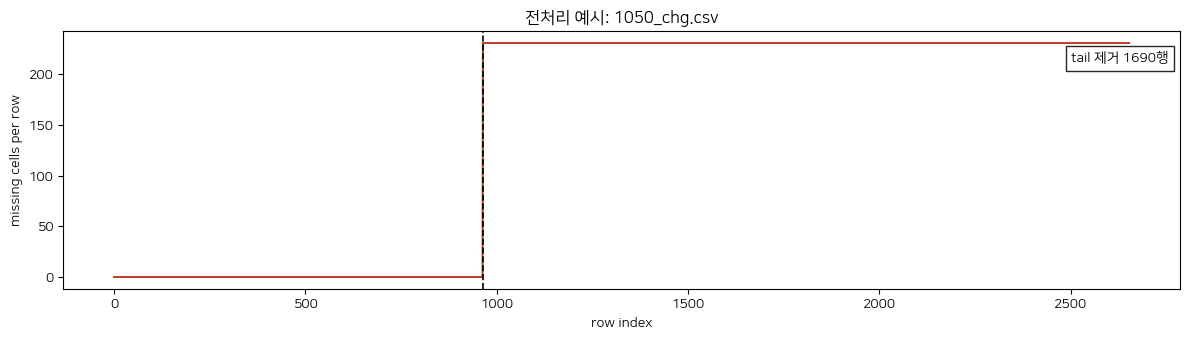

전처리 요약: 전체 111개 파일 중 가장 크게 정리된 파일은 1050_chg.csv이며, tail에서 1690행이 제거되었습니다.
train 전체 결측 셀은 391,147개에서 0개로 줄어듭니다.


In [37]:
def summarize_preprocess_effect(path: Path, split_name: str) -> dict:
    raw_df = pd.read_csv(path)
    tail_trimmed_df = trim_all_null_tail(raw_df)
    datetime_removed = 0
    if {'Date', 'Time'}.issubset(tail_trimmed_df.columns):
        dt = pd.to_datetime(
            tail_trimmed_df['Date'].astype(str).str.strip() + ' ' + tail_trimmed_df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        datetime_removed = int((~dt.notna()).sum())
    prepared_df = prepare_raw_frame(path)
    feature_df = build_row_feature_frame(prepared_df) if len(prepared_df) else pd.DataFrame()
    return {
        'split': split_name,
        'file': path.name,
        'raw_rows': int(len(raw_df)),
        'after_tail_trim_rows': int(len(tail_trimmed_df)),
        'final_rows': int(len(prepared_df)),
        'tail_removed_rows': int(len(raw_df) - len(tail_trimmed_df)),
        'datetime_removed_rows': int(datetime_removed),
        'raw_missing_cells': int(raw_df.isna().sum().sum()),
        'final_missing_cells': int(prepared_df.isna().sum().sum()),
        'feature_columns': int(feature_df.shape[1]),
    }

preprocess_rows = []
for path in sorted(TRAIN_DIR.glob('*.csv')):
    preprocess_rows.append(summarize_preprocess_effect(path, 'train'))
for test_name in TEST_FILES:
    preprocess_rows.append(summarize_preprocess_effect(TEST_DIR / test_name, 'test'))

preprocess_df = pd.DataFrame(preprocess_rows)
preprocess_summary_df = preprocess_df.groupby('split', as_index=False).agg({
    'file': 'count',
    'raw_rows': 'mean',
    'tail_removed_rows': 'sum',
    'datetime_removed_rows': 'sum',
    'raw_missing_cells': 'sum',
    'final_missing_cells': 'sum',
}).rename(columns={
    'split': '구분',
    'file': '파일 수',
    'raw_rows': '평균 원본 행 수',
    'tail_removed_rows': 'tail 제거 행 수 합계',
    'datetime_removed_rows': '시간축 제거 행 수 합계',
    'raw_missing_cells': '원본 결측 셀 수 합계',
    'final_missing_cells': '전처리 후 결측 셀 수 합계',
})

preprocess_focus_df = preprocess_df.sort_values(
    ['tail_removed_rows', 'datetime_removed_rows', 'raw_missing_cells', 'file'],
    ascending=[False, False, False, True],
).head(8).rename(columns={
    'split': '구분',
    'file': '파일',
    'raw_rows': '원본 행 수',
    'after_tail_trim_rows': 'tail 정리 후 행 수',
    'final_rows': '최종 행 수',
    'tail_removed_rows': 'tail 제거 행 수',
    'datetime_removed_rows': '시간축 제거 행 수',
    'raw_missing_cells': '원본 결측 셀 수',
    'final_missing_cells': '최종 결측 셀 수',
    'feature_columns': '특징 수',
})

display(preprocess_summary_df)
display(preprocess_focus_df)

focus_row = preprocess_df.sort_values(
    ['tail_removed_rows', 'datetime_removed_rows', 'raw_missing_cells'],
    ascending=[False, False, False],
).iloc[0]
focus_path = (TRAIN_DIR if focus_row['split'] == 'train' else TEST_DIR) / focus_row['file']
focus_raw_df = pd.read_csv(focus_path)
row_missing = focus_raw_df.isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(row_missing.to_numpy(dtype=float), color='#c0392b', linewidth=1.4)
ax.axvline(int(focus_row['after_tail_trim_rows']) - 1, color='black', linestyle='--', linewidth=1.2)
ax.set_title(f"전처리 예시: {focus_row['file']}")
ax.set_xlabel('row index')
ax.set_ylabel('missing cells per row')
ax.text(
    0.99,
    0.92,
    f"tail 제거 {int(focus_row['tail_removed_rows'])}행",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.85),
)
plt.tight_layout()
plt.show()

preprocess_focus_row = preprocess_df.sort_values(
    ['tail_removed_rows', 'datetime_removed_rows', 'raw_missing_cells'],
    ascending=[False, False, False],
).iloc[0]

print(
    f"전처리 요약: 전체 {len(preprocess_df)}개 파일 중 가장 크게 정리된 파일은 "
    f"{preprocess_focus_row['file']}이며, tail에서 {int(preprocess_focus_row['tail_removed_rows'])}행이 제거되었습니다."
)
print(
    f"train 전체 결측 셀은 {int(preprocess_df.loc[preprocess_df['split'] == 'train', 'raw_missing_cells'].sum()):,}개에서 "
    f"{int(preprocess_df.loc[preprocess_df['split'] == 'train', 'final_missing_cells'].sum()):,}개로 줄어듭니다."
)

## 모델 평가 함수 준비

- 아래 셀들은 바로 결과를 출력하지 않습니다.
- 설정 탐색과 최종 평가에 쓸 점수 계산 함수와 고장 단서 함수를 먼저 정의합니다.

### 이상 점수 계산

- 입력: 학습된 모드별 suite와 한 파일의 원본 시계열
- 처리: 윈도우 점수를 행 단위 점수로 복원하고 임계값 이상 구간을 찾음
- 산출: 점수 시계열, 예측 마스크, 예측 구간 요약

In [38]:
from __future__ import annotations

def score_file(raw_file: Path | str, suite: ModeSuite, label_file: Path | str | None = None) -> dict:
    raw_df = prepare_raw_frame(raw_file)
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
    active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    transformed = suite.reducer.transform(suite.scaler.transform(windows))
    window_scores = -suite.model.decision_function(transformed).reshape(-1)
    raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)
    point_scores = raw_point_scores * active_mask

    pred_bin = (point_scores >= suite.threshold).astype(int)
    pred_bin = pred_bin * active_mask

    result = {
        'test_name': Path(raw_file).name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)),
        'active_strategy': active_debug['strategy'],
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)),
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)),
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)),
        'raw_score_max': float(np.max(raw_point_scores)),
        'score_q95': float(np.quantile(point_scores, 0.95)),
        'score_q99': float(np.quantile(point_scores, 0.99)),
        'score_max': float(np.max(point_scores)),
    }
    if label_file is not None and Path(label_file).exists():
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        size = min(len(labels), len(pred_bin))
        gt = labels[:size]
        pred = pred_bin[:size]
        result['gt_ratio'] = float(np.mean(gt))
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

def summarize_pred_intervals(pred_intervals: list[list[float]], n_rows: int) -> dict:
    if n_rows <= 0 or not pred_intervals:
        return {
            'n_pred_intervals': 0,
            'largest_interval_ratio': 0.0,
            'largest_interval_end_ratio': 0.0,
            'tail_interval_exists': False,
        }
    rows = []
    for start, end in pred_intervals:
        start_i = int(start)
        end_i = int(end)
        length = max(0, end_i - start_i + 1)
        rows.append({
            'start': start_i,
            'end': end_i,
            'length_ratio': length / max(n_rows, 1),
            'end_ratio': end_i / max(n_rows - 1, 1),
        })
    interval_df = pd.DataFrame(rows)
    largest = interval_df.sort_values('length_ratio', ascending=False).iloc[0]
    return {
        'n_pred_intervals': int(len(interval_df)),
        'largest_interval_ratio': float(largest['length_ratio']),
        'largest_interval_end_ratio': float(largest['end_ratio']),
        'tail_interval_exists': bool(((interval_df['end_ratio'] >= 0.90) & (interval_df['length_ratio'] >= 0.02)).any()),
    }

### 고장 단서 계산

- 입력: 파일별 점수 시계열과 행 단위 특징
- 처리: 용량불량, 용접불량, 센싱와이어불량, 센서불량 단서를 각각 계산
- 산출: 고장별 점수와 최종 판정 보조 정보

In [39]:
from __future__ import annotations

def _safe_quantile(values, q: float) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.quantile(arr, q))

def _safe_mean(values) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.mean(arr))

def compute_fault_features(raw_df: pd.DataFrame) -> dict[str, float]:
    cv_cols, temp_cols = extract_signal_groups(raw_df)
    features: dict[str, float] = {}

    if cv_cols:
        voltage = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce')
        row_spread = voltage.max(axis=1) - voltage.min(axis=1)
        tail_n = max(10, len(voltage) // 5)
        tail_spread = row_spread.tail(tail_n)
        row_jump = voltage.diff().abs().max(axis=1)
        row_median = voltage.median(axis=1)
        low_gap = row_median - voltage.min(axis=1)
        adjacent = voltage.reindex(sorted(cv_cols), axis=1).diff(axis=1).abs()
        adjacent = adjacent.iloc[:, 1:] if adjacent.shape[1] > 1 else adjacent
        cell_means = voltage.mean(axis=0)
        features['voltage_spread_p95'] = _safe_quantile(row_spread, 0.95)
        features['tail_voltage_spread_mean'] = _safe_mean(tail_spread)
        features['voltage_jump_p99'] = _safe_quantile(row_jump, 0.99)
        features['adjacent_gap_p99'] = _safe_quantile(adjacent.max(axis=1), 0.99) if adjacent.shape[1] > 0 else 0.0
        features['adjacent_gap_mean'] = _safe_mean(adjacent.max(axis=1)) if adjacent.shape[1] > 0 else 0.0
        features['persistent_low_cell_gap'] = float(max(0.0, cell_means.median() - cell_means.min()))
        features['single_cell_low_gap_p95'] = _safe_quantile(low_gap, 0.95)
    else:
        for key in ('voltage_spread_p95','tail_voltage_spread_mean','voltage_jump_p99','adjacent_gap_p99','adjacent_gap_mean','persistent_low_cell_gap','single_cell_low_gap_p95'):
            features[key] = 0.0

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce')
        temp_median = temp.median(axis=1)
        temp_dev = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_range = temp.max(axis=1) - temp.min(axis=1)
        temp_means = temp.mean(axis=0)
        temp_gap = max(float(temp_means.max() - temp_means.median()), float(temp_means.median() - temp_means.min()))
        features['temp_outlier_p99'] = _safe_quantile(temp_dev, 0.99)
        features['temp_range_p95'] = _safe_quantile(temp_range, 0.95)
        features['temp_persistent_gap'] = temp_gap
    else:
        features['temp_outlier_p99'] = 0.0
        features['temp_range_p95'] = 0.0
        features['temp_persistent_gap'] = 0.0

    return features

def robust_stat_summary(values) -> dict[str, float]:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {'median': 0.0, 'iqr': 1e-6}
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    return {'median': float(np.median(arr)), 'iqr': float(max(q3 - q1, 1e-6))}

def robust_excess(value: float, baseline: dict[str, float]) -> float:
    return float(max(0.0, (value - baseline['median']) / baseline['iqr']))

FAULT_CONTRIBUTIONS = {
    'capacity_fault': {'tail_voltage_spread_mean': 0.55, 'voltage_jump_p99': 0.30, 'voltage_spread_p95': 0.15},
    'weld_fault': {'persistent_low_cell_gap': 0.45, 'single_cell_low_gap_p95': 0.25},
    'sensing_wire_fault': {'adjacent_gap_p99': 0.65, 'adjacent_gap_mean': 0.20, 'voltage_spread_p95': 0.15},
    'sensor_fault': {'temp_outlier_p99': 0.55, 'temp_range_p95': 0.25, 'temp_persistent_gap': 0.20},
}

def build_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    feature_rows = []
    for battery_id in list_train_ids(mode, EXCLUDED_PAIR_IDS):
        raw_df = prepare_raw_frame(TRAIN_DIR / f'{battery_id}_{mode}.csv')
        feature_rows.append(compute_fault_features(raw_df))
    feature_names = feature_rows[0].keys()
    return {feature_name: robust_stat_summary([row[feature_name] for row in feature_rows]) for feature_name in feature_names}

def get_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    if mode not in FAULT_BASELINE_CACHE:
        FAULT_BASELINE_CACHE[mode] = build_fault_baseline(mode)
    return FAULT_BASELINE_CACHE[mode]

def compute_fault_support(raw_df: pd.DataFrame, mode: str) -> dict:
    features = compute_fault_features(raw_df)
    baseline = get_fault_baseline(mode)
    scores = {
        fault_name: float(sum(weight * robust_excess(features[feature_name], baseline[feature_name]) for feature_name, weight in weight_map.items()))
        for fault_name, weight_map in FAULT_CONTRIBUTIONS.items()
    }
    top_fault = max(scores, key=scores.get)
    return {'fault_scores': scores, 'top_fault_name': top_fault, 'top_fault_score': float(scores[top_fault])}

## 설정 탐색 함수 준비

- 아래 셀들도 즉시 결과를 만들지 않고 탐색용 함수만 정의합니다.
- 실제 탐색은 뒤의 `설정 탐색 실행` 셀에서 한 번에 수행합니다.
- 탐색 순서는 `PCA -> OCSVM -> 후처리`입니다.

### 모드별 점수 구조

- 입력: 충전 또는 방전 모드의 학습 기록
- 처리: 표준화기, PCA, OCSVM, 임계값을 하나의 구조체로 묶음
- 산출: 이후 평가에 공통으로 쓰는 `ModeSuite`

In [40]:
from __future__ import annotations

@dataclass
class ModeSuite:
    mode: str
    train_ids: list[int]
    fit_ids: list[int]
    calib_ids: list[int]
    feature_columns: list[str]
    win_size: int
    step_size: int
    active_padding: int
    pca_components: int
    nu: float
    threshold_quantile: float
    max_fit_windows: int
    scaler: StandardScaler
    reducer: PCA
    model: OneClassSVM
    threshold: float

def score_raw_df(raw_df: pd.DataFrame, suite: ModeSuite, labels: np.ndarray | None = None, name: str = 'raw') -> dict:
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
    active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    if len(windows) == 0:
        raw_point_scores = np.zeros(len(row_features), dtype=float)
    else:
        transformed = suite.reducer.transform(suite.scaler.transform(windows))
        window_scores = -suite.model.decision_function(transformed).reshape(-1)
        raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)

    point_scores = raw_point_scores * active_mask
    pred_bin = (point_scores >= suite.threshold).astype(int) * active_mask

    result = {
        'test_name': name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)) if len(active_mask) else 0.0,
        'active_strategy': active_debug['strategy'],
        'row_features': row_features,
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)) if len(pred_bin) else 0.0,
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)) if len(raw_point_scores) else 0.0,
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)) if len(raw_point_scores) else 0.0,
        'raw_score_max': float(np.max(raw_point_scores)) if len(raw_point_scores) else 0.0,
        'score_q95': float(np.quantile(point_scores, 0.95)) if len(point_scores) else 0.0,
        'score_q99': float(np.quantile(point_scores, 0.99)) if len(point_scores) else 0.0,
        'score_max': float(np.max(point_scores)) if len(point_scores) else 0.0,
    }
    if labels is not None:
        size = min(len(labels), len(pred_bin))
        gt = labels[:size].astype(int)
        pred = pred_bin[:size].astype(int)
        result['gt_ratio'] = float(np.mean(gt)) if len(gt) else 0.0
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

### 학습용·검증용 분리와 PCA 후보 생성

- 입력: 사용하기로 한 train pair
- 처리: 내부 학습용과 설정 검증용으로 분리하고, 분산 유지율 기반 PCA 후보를 만듦
- 산출: 모드별 학습 기록과 PCA 후보 목록

In [41]:
from __future__ import annotations

def split_train_ids_for_calibration(mode: str, cfg: dict) -> tuple[list[int], list[int]]:
    ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    rng = np.random.default_rng(SEED + (0 if mode == 'chg' else 1))
    ids = list(rng.permutation(ids))
    calib_n = max(int(round(len(ids) * float(cfg['calibration_ratio']))), int(cfg['min_calibration_ids']))
    calib_n = min(max(calib_n, 1), max(len(ids) - 1, 1))
    calib_ids = sorted(ids[:calib_n])
    fit_ids = sorted(ids[calib_n:])
    if not fit_ids:
        fit_ids = calib_ids[:-1]
        calib_ids = calib_ids[-1:]
    return fit_ids, calib_ids

def build_training_records(train_ids: list[int], mode: str, win_size: int, step_size: int, active_padding: int) -> list[dict]:
    records = []
    for battery_id in train_ids:
        raw_path = TRAIN_DIR / f'{battery_id}_{mode}.csv'
        raw_df = prepare_raw_frame(raw_path)
        row_features = build_row_feature_frame(raw_df)
        windows, starts = make_windows(row_features, win_size=win_size, step_size=step_size)
        if len(windows) == 0:
            continue
        active_mask, active_debug = build_active_mask(row_features, padding=active_padding, return_debug=True)
        records.append({
            'battery_id': battery_id,
            'raw_df': raw_df,
            'row_features': row_features,
            'windows': windows,
            'starts': starts,
            'active_mask': active_mask,
            'active_debug': active_debug,
        })
    return records

def infer_pca_candidates(fit_X: np.ndarray, variance_targets: tuple[float, ...], max_candidates: int = 6) -> list[int]:
    n_samples, n_features = fit_X.shape
    max_components = max(2, min(n_samples, n_features) - 1)
    scaled = StandardScaler().fit_transform(fit_X)
    candidates = set()
    candidates.add(int(max(2, min(round(math.sqrt(n_features)), max_components))))
    if max_components >= 2:
        try:
            mle = PCA(n_components='mle', svd_solver='full', random_state=SEED)
            mle.fit(scaled)
            candidates.add(int(max(2, min(int(mle.n_components_), max_components))))
        except Exception:
            pass
    full = PCA(n_components=max_components, random_state=SEED)
    full.fit(scaled)
    cumulative = np.cumsum(full.explained_variance_ratio_)
    for target in variance_targets:
        idx = int(np.searchsorted(cumulative, float(target), side='left')) + 1
        candidates.add(int(max(2, min(idx, max_components))))
    if not candidates:
        candidates.add(int(max(2, min(round(math.sqrt(n_features)), max_components))))
    candidates = sorted(candidates)
    if len(candidates) > int(max_candidates):
        positions = np.linspace(0, len(candidates) - 1, num=int(max_candidates))
        candidates = sorted({candidates[int(round(pos))] for pos in positions})
    return candidates

def infer_nu_candidates(n_windows: int) -> list[float]:
    base = 1.0 / max(math.sqrt(max(n_windows, 1)), 1.0)
    candidates = {
        max(0.005, min(0.15, base * 0.5)),
        max(0.005, min(0.15, base * 0.75)),
        max(0.005, min(0.15, base)),
        max(0.005, min(0.15, base * 1.25)),
        max(0.005, min(0.15, base * 1.5)),
        max(0.005, min(0.15, base * 2.0)),
        max(0.005, min(0.15, base * 3.0)),
    }
    return sorted(round(float(v), 6) for v in candidates)

def infer_threshold_quantile_candidates() -> list[float]:
    return [0.9850, 0.9900, 0.9925, 0.9950, 0.9970, 0.9980, 0.9990, 0.9995]

def pca_candidate_rank(row: dict) -> tuple[float, float, float, float]:
    return (
        float(row['objective']),
        float(row['retained_variance']),
        -float(row['reconstruction_mse']),
        -float(row['pca_components']),
    )

def evaluate_pca_stage(fit_records: list[dict], calib_records: list[dict], cfg: dict) -> dict:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= cfg['max_fit_windows'] else X_train[rng.choice(len(X_train), cfg['max_fit_windows'], replace=False)]
    calib_X = np.concatenate([record['windows'] for record in calib_records], axis=0)

    search_rows = []
    best = None
    pca_candidates = infer_pca_candidates(fit_X, tuple(cfg['variance_targets']), int(cfg['max_pca_candidates']))
    for pca_components in pca_candidates:
        scaler = StandardScaler()
        scaled_fit = scaler.fit_transform(fit_X)
        reducer = PCA(n_components=int(pca_components), random_state=SEED)
        reducer.fit(scaled_fit)
        retained_variance = float(np.sum(reducer.explained_variance_ratio_))

        scaled_calib = scaler.transform(calib_X)
        reduced_calib = reducer.transform(scaled_calib)
        recon_calib = reducer.inverse_transform(reduced_calib)
        reconstruction_mse = float(np.mean((scaled_calib - recon_calib) ** 2))
        compression_ratio = float(pca_components / max(fit_X.shape[1], 1))
        objective = retained_variance - reconstruction_mse - (0.02 * compression_ratio)

        row = {
            'pca_components': int(pca_components),
            'retained_variance': retained_variance,
            'reconstruction_mse': reconstruction_mse,
            'compression_ratio': compression_ratio,
            'objective': objective,
        }
        search_rows.append(row)
        if best is None or pca_candidate_rank(row) > pca_candidate_rank(best):
            best = row

    return {
        'best_row': dict(best),
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

### 합성 고장 주입

- 입력: 정상 train 기록
- 처리: 전압 편차, 셀 간 불균형, 온도 이상 같은 인위적 교란을 주입
- 산출: 설정 탐색에 쓰는 synthetic fault case

In [42]:
from __future__ import annotations

def _clip_range(n_rows: int, start_ratio: float, end_ratio: float) -> tuple[int, int]:
    start = max(0, min(n_rows - 2, int(round(n_rows * start_ratio))))
    end = max(start + 1, min(n_rows - 1, int(round(n_rows * end_ratio))))
    return start, end

def inject_fault_case(raw_df: pd.DataFrame, fault_type: str, mode: str, seed: int) -> tuple[pd.DataFrame, np.ndarray]:
    out = raw_df.copy()
    labels = np.zeros(len(out), dtype=int)
    cv_cols, temp_cols = extract_signal_groups(out)
    rng = np.random.default_rng(seed)
    n_rows = len(out)
    if n_rows < 40:
        return out, labels

    if cv_cols:
        cell_v = out[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        spread = (cell_v.max(axis=1) - cell_v.min(axis=1)).to_numpy(dtype=float)
        delta_v = float(np.clip(max(np.quantile(spread, 0.95) * 1.2, 0.02), 0.02, 0.08))
    else:
        delta_v = 0.04
    if temp_cols:
        temp = out[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_range = (temp.max(axis=1) - temp.min(axis=1)).to_numpy(dtype=float)
        delta_t = float(np.clip(max(np.quantile(temp_range, 0.95) * 1.5, 3.0), 3.0, 15.0))
    else:
        delta_t = 6.0

    if fault_type == 'capacity_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.70, 0.95)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        ramp = np.linspace(0.0, delta_v * 1.5, end - start + 1)
        sign = 1.0 if mode == 'chg' else -1.0
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + sign * ramp
        labels[start:end + 1] = 1
    elif fault_type == 'weld_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.35, 0.80)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) - delta_v * 1.5
        labels[start:end + 1] = 1
    elif fault_type == 'sensing_wire_fault' and len(cv_cols) >= 2:
        start, end = _clip_range(n_rows, 0.55, 0.92)
        col = cv_cols[int(rng.integers(1, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_v * 2.0
        labels[start:end + 1] = 1
    elif fault_type == 'sensor_fault' and temp_cols:
        start, end = _clip_range(n_rows, 0.50, 0.90)
        col = temp_cols[int(rng.integers(0, len(temp_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_t
        labels[start:end + 1] = 1
    else:
        start, end = _clip_range(n_rows, 0.55, 0.90)
        labels[start:end + 1] = 1
    return handle_missing_numeric(out), labels

def build_synthetic_cases(calib_records: list[dict], mode: str) -> list[dict]:
    cases = []
    fault_types = ('capacity_fault', 'weld_fault', 'sensing_wire_fault', 'sensor_fault')
    for record in calib_records:
        for fault_idx, fault_type in enumerate(fault_types):
            raw_df, labels = inject_fault_case(
                record['raw_df'],
                fault_type=fault_type,
                mode=mode,
                seed=SEED + record['battery_id'] * 10 + fault_idx,
            )
            if labels.sum() == 0:
                continue
            cases.append({
                'battery_id': record['battery_id'],
                'fault_type': fault_type,
                'raw_df': raw_df,
                'labels': labels,
            })
    return cases

### 모드별 학습

- 입력: 한 모드의 학습 기록과 선택된 PCA/nu/threshold
- 처리: scaler, PCA, OCSVM을 실제로 적합
- 산출: 해당 모드의 학습 완료 suite

In [43]:
from __future__ import annotations

def train_mode_suite_from_records(
    mode: str,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    *,
    pca_components: int,
    nu: float,
    threshold_quantile: float,
    win_size: int,
    step_size: int,
    active_padding: int,
    max_fit_windows: int,
) -> ModeSuite:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= max_fit_windows else X_train[rng.choice(len(X_train), max_fit_windows, replace=False)]

    scaler = StandardScaler()
    reducer = PCA(n_components=int(pca_components), random_state=SEED)
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=float(nu))

    scaled_fit = scaler.fit_transform(fit_X)
    reduced_fit = reducer.fit_transform(scaled_fit)
    model.fit(reduced_fit)

    train_active_scores = []
    for record in fit_records:
        transformed = reducer.transform(scaler.transform(record['windows']))
        window_scores = -model.decision_function(transformed).reshape(-1)
        point_scores = window_scores_to_point_scores(window_scores, len(record['row_features']), win_size, record['starts'])
        point_scores = point_scores * record['active_mask']
        active_scores = point_scores[record['active_mask'] == 1]
        if len(active_scores) == 0:
            active_scores = point_scores
        train_active_scores.append(active_scores)

    concat_scores = np.concatenate(train_active_scores, axis=0)
    threshold = float(np.quantile(concat_scores, float(threshold_quantile)))

    return ModeSuite(
        mode=mode,
        train_ids=train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        feature_columns=fit_records[0]['row_features'].columns.tolist(),
        win_size=win_size,
        step_size=step_size,
        active_padding=active_padding,
        pca_components=int(pca_components),
        nu=float(nu),
        threshold_quantile=float(threshold_quantile),
        max_fit_windows=int(max_fit_windows),
        scaler=scaler,
        reducer=reducer,
        model=model,
        threshold=threshold,
    )

### 단계별 후보 평가

- 입력: calibration 기록과 synthetic fault case
- 처리: PCA 단계, OCSVM 단계, 후처리 단계 후보를 각각 점수화
- 산출: 단계별 후보 순위표와 선택 기준

In [44]:
from __future__ import annotations

def candidate_postfilter_grid(win_size: int) -> list[dict]:
    return [
        {
            'low_ratio': low_ratio,
            'merge_gap_rows': int(gap),
            'min_interval_len': int(min_len),
            'persistent_ratio_threshold': float(persist),
            'head_interval_start_ratio_max': 0.05,
            'tail_interval_end_ratio_min': 0.90,
        }
        for low_ratio, gap, min_len, persist in itertools.product(
            (0.55, 0.65, 0.75),
            (win_size, win_size * 2, win_size * 3),
            (max(10, win_size // 2), win_size, win_size * 2),
            (0.45, 0.55, 0.70),
        )
    ]

def evaluate_raw_candidate_objective(normal_details: list[dict], synthetic_details: list[dict]) -> dict:
    normal_pred = float(np.mean([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0
    normal_alarm_rate = float(np.mean([detail['pred_ratio'] > 0.01 for detail in normal_details])) if normal_details else 0.0
    normal_max_pred = float(np.max([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0

    synth_metrics = []
    for detail in synthetic_details:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - (1.5 * normal_pred) - (0.75 * normal_alarm_rate) - (0.25 * normal_max_pred)
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_details': normal_details,
        'synthetic_details': synthetic_details,
    }

def evaluate_candidate_objective(normal_details: list[dict], synthetic_details: list[dict], post_cfg: dict) -> dict:
    normal_outputs = [generalized_postfilter(detail, post_cfg) for detail in normal_details]
    synth_outputs = [generalized_postfilter(detail, post_cfg) for detail in synthetic_details]

    normal_pred = float(np.mean([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    normal_alarm_rate = float(np.mean([detail['final_pred_ratio'] > 0.01 for detail in normal_outputs])) if normal_outputs else 0.0
    normal_max_pred = float(np.max([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    synth_metrics = []
    for detail in synth_outputs:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['final_pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - (1.5 * normal_pred) - (0.75 * normal_alarm_rate) - (0.25 * normal_max_pred)
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_outputs': normal_outputs,
        'synthetic_outputs': synth_outputs,
    }

def candidate_rank(row: dict) -> tuple[float, float, float, float, float, float]:
    return (
        float(row['objective']),
        -float(row['normal_alarm_rate']),
        -float(row['normal_pred_ratio']),
        -float(row['normal_max_pred_ratio']),
        float(row['synthetic_recall']),
        float(row['threshold_quantile']),
    )

def search_detector_stage(
    mode: str,
    *,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    calib_records: list[dict],
    synthetic_cases: list[dict],
    pca_components: int,
    cfg: dict,
) -> dict:
    fit_X = np.concatenate([record['windows'] for record in fit_records], axis=0)
    nu_candidates = cfg['nu_candidates'] or infer_nu_candidates(len(fit_X))
    threshold_candidates = cfg['threshold_quantile_candidates'] or infer_threshold_quantile_candidates()

    search_rows = []
    best = None
    for nu in nu_candidates:
        for threshold_quantile in threshold_candidates:
            suite = train_mode_suite_from_records(
                mode=mode,
                train_ids=train_ids,
                fit_ids=fit_ids,
                calib_ids=calib_ids,
                fit_records=fit_records,
                pca_components=pca_components,
                nu=nu,
                threshold_quantile=threshold_quantile,
                win_size=cfg['win_size'],
                step_size=cfg['step_size'],
                active_padding=cfg['active_padding'],
                max_fit_windows=cfg['max_fit_windows'],
            )

            normal_details = []
            for record in calib_records:
                detail = score_raw_df(record['raw_df'], suite, labels=np.zeros(len(record['raw_df']), dtype=int), name=f"{record['battery_id']}_{mode}_normal")
                support = compute_fault_support(record['raw_df'], mode)
                detail['fault_scores'] = support['fault_scores']
                detail['top_fault_name'] = support['top_fault_name']
                detail['top_fault_score'] = support['top_fault_score']
                normal_details.append(detail)

            synthetic_details = []
            for case in synthetic_cases:
                detail = score_raw_df(case['raw_df'], suite, labels=case['labels'], name=f"{case['battery_id']}_{case['fault_type']}")
                support = compute_fault_support(case['raw_df'], mode)
                detail['fault_scores'] = support['fault_scores']
                detail['top_fault_name'] = support['top_fault_name']
                detail['top_fault_score'] = support['top_fault_score']
                detail['labels'] = case['labels']
                synthetic_details.append(detail)

            candidate = evaluate_raw_candidate_objective(normal_details, synthetic_details)
            row = {
                'mode': mode,
                'pca_components': int(pca_components),
                'nu': float(nu),
                'threshold_quantile': float(threshold_quantile),
                'objective': candidate['objective'],
                'normal_pred_ratio': candidate['normal_pred_ratio'],
                'normal_alarm_rate': candidate['normal_alarm_rate'],
                'normal_max_pred_ratio': candidate['normal_max_pred_ratio'],
                'synthetic_f1': candidate['synthetic_f1'],
                'synthetic_precision': candidate['synthetic_precision'],
                'synthetic_recall': candidate['synthetic_recall'],
            }
            search_rows.append(row)
            if best is None or candidate_rank(row) > candidate_rank(best['row']):
                best = {
                    'row': row,
                    'suite': suite,
                    'normal_details': candidate['normal_details'],
                    'synthetic_details': candidate['synthetic_details'],
                }

    return {
        'best_row': dict(best['row']),
        'suite': best['suite'],
        'normal_details': best['normal_details'],
        'synthetic_details': best['synthetic_details'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

def search_generalized_postfilter_stage(normal_details: list[dict], synthetic_details: list[dict], cfg: dict) -> dict:
    search_rows = []
    best = None
    post_grid = candidate_postfilter_grid(cfg['win_size'])
    for post_cfg in post_grid:
        candidate = evaluate_candidate_objective(normal_details, synthetic_details, post_cfg)
        row = {
            **post_cfg,
            'objective': candidate['objective'],
            'normal_pred_ratio': candidate['normal_pred_ratio'],
            'normal_alarm_rate': candidate['normal_alarm_rate'],
            'normal_max_pred_ratio': candidate['normal_max_pred_ratio'],
            'synthetic_f1': candidate['synthetic_f1'],
            'synthetic_precision': candidate['synthetic_precision'],
            'synthetic_recall': candidate['synthetic_recall'],
        }
        search_rows.append(row)
        if best is None or candidate_rank({**row, 'threshold_quantile': 0.0}) > candidate_rank({**best['row'], 'threshold_quantile': 0.0}):
            best = {
                'row': row,
                'generalized_cfg': dict(post_cfg),
                'normal_outputs': candidate['normal_outputs'],
                'synthetic_outputs': candidate['synthetic_outputs'],
            }

    return {
        'best_row': dict(best['row']),
        'generalized_cfg': best['generalized_cfg'],
        'normal_outputs': best['normal_outputs'],
        'synthetic_outputs': best['synthetic_outputs'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

### 기본 후처리 규칙

- 입력: raw 예측 마스크
- 처리: 짧은 잡음 제거, 가까운 구간 병합, 너무 약한 구간 제거
- 산출: 일반 후처리 최종 예측 구간

In [45]:
from __future__ import annotations

def generalized_postfilter(detail: dict, cfg: dict) -> dict:
    scores = np.asarray(detail['point_scores'], dtype=float)
    high = float(detail['score_threshold'])
    low = high * float(cfg['low_ratio'])

    above_high = scores >= high
    above_low = scores >= low
    pred = np.zeros(len(scores), dtype=int)
    for start, end in [(int(s), int(e)) for s, e in binary_to_intervals(above_low.astype(int))]:
        if above_high[start:end + 1].any():
            pred[start:end + 1] = 1

    merged = merge_close_intervals([(int(s), int(e)) for s, e in binary_to_intervals(pred)], int(cfg['merge_gap_rows']))
    filtered = np.zeros_like(pred)
    for start, end in merged:
        if end - start + 1 >= int(cfg['min_interval_len']):
            filtered[start:end + 1] = 1

    intervals = [(int(s), int(e)) for s, e in binary_to_intervals(filtered)]
    bridged_head_tail = False
    accept_reason = 'reject_fragmented'

    if intervals:
        first_start, last_end = intervals[0][0], intervals[-1][1]
        persistent = float(np.mean(filtered)) >= float(cfg['persistent_ratio_threshold'])
        head_ok = first_start / max(len(filtered) - 1, 1) <= float(cfg['head_interval_start_ratio_max'])
        tail_ok = last_end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])

        if persistent and head_ok and tail_ok:
            filtered[first_start:last_end + 1] = 1
            intervals = [(first_start, last_end)]
            accept_reason = 'generalized_bridged'
            bridged_head_tail = True
        else:
            tail_intervals = [
                (start, end)
                for start, end in intervals
                if end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])
            ]
            if tail_intervals:
                filtered = np.zeros_like(filtered)
                for start, end in tail_intervals:
                    filtered[start:end + 1] = 1
                intervals = tail_intervals
                accept_reason = 'tail_interval_detected'
            else:
                filtered = np.zeros_like(filtered)
                intervals = []
                accept_reason = 'reject_non_tail'

    return {
        **detail,
        'accept_postfilter': bool(filtered.sum() > 0),
        'accept_reason': accept_reason,
        'merged_fragment_chain': False,
        'tail_backpadded': False,
        'bridged_head_tail': bool(bridged_head_tail),
        'final_pred_bin': filtered,
        'final_pred_intervals': [[float(s), float(e)] for s, e in intervals],
        'final_pred_ratio': float(np.mean(filtered)) if len(filtered) else 0.0,
        **summarize_pred_intervals([[float(s), float(e)] for s, e in intervals], len(filtered)),
    }

### 고장 인지 후처리 규칙

- 입력: raw 예측 마스크와 고장 단서 점수
- 처리: 고장 가능성이 높을 때는 구간을 보강하고, 약할 때는 기각
- 산출: 고장 단서를 반영한 최종 예측 구간

In [46]:
from __future__ import annotations

def fault_aware_postfilter(base_detail: dict, support: dict, cfg: dict) -> dict:
    out = dict(base_detail)
    out['fault_scores'] = support['fault_scores']
    out['top_fault_name'] = support['top_fault_name']
    out['top_fault_score'] = support['top_fault_score']
    out['merged_fragment_chain'] = False
    out['tail_backpadded'] = False

    if support['top_fault_score'] < float(cfg['fault_reject_threshold']) and out['final_pred_ratio'] < float(cfg['fault_reject_pred_ratio_max']):
        pred = np.zeros_like(out['final_pred_bin'])
        out['final_pred_bin'] = pred
        out['final_pred_intervals'] = []
        out['final_pred_ratio'] = 0.0
        out['accept_postfilter'] = False
        out['accept_reason'] = 'fault_gate_reject'
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
        return out

    raw_intervals = [(int(s), int(e)) for s, e in out['pred_intervals']]
    n_rows = len(out['final_pred_bin'])

    if support['top_fault_score'] >= float(cfg['fault_boost_threshold']) and raw_intervals:
        if out['tail_interval_exists'] and len(raw_intervals) >= int(cfg['fragmented_merge_min_intervals']):
            merged_components = merge_close_intervals(raw_intervals, int(cfg['local_fragment_gap_rows']))
            if len(merged_components) >= 2:
                anchor_start = merged_components[-2][0]
                end_idx = merged_components[-1][1]
                merged_components = merged_components[:-2] + [(anchor_start, end_idx)]
            pred = np.zeros_like(out['final_pred_bin'])
            for start_idx, end_idx in merged_components:
                pred[start_idx:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(s), float(e)] for s, e in merged_components]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_component_merge'
            out['merged_fragment_chain'] = True
        elif out['tail_interval_exists'] and float(out['pred_ratio']) < 0.10:
            start_idx, end_idx = raw_intervals[0][0], raw_intervals[-1][1]
            backpad = min(int(round(n_rows * float(cfg['tail_backpad_ratio']))), int(cfg['tail_backpad_cap_rows']))
            padded_start = max(0, start_idx - backpad)
            pred = np.zeros_like(out['final_pred_bin'])
            pred[padded_start:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(padded_start), float(end_idx)]]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_tail_backpad'
            out['tail_backpadded'] = True

    intervals = [[float(s), float(e)] for s, e in binary_to_intervals(out['final_pred_bin'])]
    out['final_pred_intervals'] = intervals
    if intervals:
        lengths = [int(end) - int(start) + 1 for start, end in intervals]
        largest_idx = int(np.argmax(lengths))
        out['n_pred_intervals'] = len(intervals)
        out['largest_interval_ratio'] = lengths[largest_idx] / max(len(out['final_pred_bin']), 1)
        out['largest_interval_end_ratio'] = int(intervals[largest_idx][1]) / max(len(out['final_pred_bin']) - 1, 1)
        out['tail_interval_exists'] = bool(any(end / max(len(out['final_pred_bin']) - 1, 1) >= float(cfg['tail_interval_end_ratio_min']) for _, end in intervals))
    else:
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
    return out

def derive_fault_aware_cfg(mode: str, generalized_result: dict, win_size: int) -> dict:
    normal_outputs = generalized_result['normal_outputs']
    synthetic_outputs = generalized_result['synthetic_outputs']
    normal_supports = np.asarray([detail['top_fault_score'] for detail in normal_outputs], dtype=float)
    synthetic_supports = np.asarray([detail['top_fault_score'] for detail in synthetic_outputs], dtype=float)
    normal_pred_ratios = np.asarray([detail['final_pred_ratio'] for detail in normal_outputs], dtype=float)

    fragmented_counts = []
    fragmented_gaps = []
    tail_backpad_rows = []
    tail_backpad_ratios = []
    for detail in synthetic_outputs:
        intervals = [(int(s), int(e)) for s, e in detail['pred_intervals']]
        gt = np.asarray(detail['labels'], dtype=int)
        gt_intervals = [(int(s), int(e)) for s, e in binary_to_intervals(gt)]
        if detail['tail_interval_exists'] and len(intervals) >= 2:
            fragmented_counts.append(len(intervals))
            for (s1, e1), (s2, e2) in zip(intervals[:-1], intervals[1:]):
                fragmented_gaps.append(max(0, s2 - e1 - 1))
        if detail['tail_interval_exists'] and intervals and gt_intervals:
            start_error = max(0, intervals[0][0] - gt_intervals[0][0])
            if start_error > 0:
                tail_backpad_rows.append(start_error)
                tail_backpad_ratios.append(start_error / max(len(detail['final_pred_bin']), 1))

    fault_cfg = {
        **generalized_result['generalized_cfg'],
        'fault_reject_threshold': float(np.quantile(normal_supports, 0.95)) if normal_supports.size else 0.0,
        'fault_reject_pred_ratio_max': float(np.quantile(normal_pred_ratios, 0.95)) if normal_pred_ratios.size else 0.0,
        'fault_boost_threshold': float(max(
            np.quantile(normal_supports, 0.95) if normal_supports.size else 0.0,
            np.quantile(synthetic_supports, 0.25) if synthetic_supports.size else 0.0,
        )),
        'fragmented_merge_min_intervals': int(max(2, round(np.median(fragmented_counts)))) if fragmented_counts else 2,
        'local_fragment_gap_rows': int(max(
            win_size,
            round(np.quantile(fragmented_gaps, 0.75)) if fragmented_gaps else win_size * 2,
        )),
        'tail_backpad_ratio': float(np.clip(np.median(tail_backpad_ratios) if tail_backpad_ratios else 0.02, 0.005, 0.10)),
        'tail_backpad_cap_rows': int(max(win_size, round(np.quantile(tail_backpad_rows, 0.90)) if tail_backpad_rows else win_size * 4)),
    }
    return fault_cfg

### 최종 설정 선택

- 입력: 단계별 후보 평가 결과
- 처리: `PCA -> OCSVM -> 후처리` 순서로 선택값을 고정
- 산출: 충전/방전별 최종 설정과 탐색 이력

In [47]:
from __future__ import annotations

def auto_calibrate_mode(mode: str, cfg: dict) -> dict:
    fit_ids, calib_ids = split_train_ids_for_calibration(mode, cfg)
    all_train_ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    fit_records = build_training_records(fit_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    calib_records = build_training_records(calib_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    if not fit_records or not calib_records:
        raise ValueError(f'Insufficient records for auto calibration: mode={mode}')

    synthetic_cases = build_synthetic_cases(calib_records, mode)

    pca_stage = evaluate_pca_stage(fit_records, calib_records, cfg)
    detector_stage = search_detector_stage(
        mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=fit_records,
        calib_records=calib_records,
        synthetic_cases=synthetic_cases,
        pca_components=int(pca_stage['best_row']['pca_components']),
        cfg=cfg,
    )
    postfilter_stage = search_generalized_postfilter_stage(
        detector_stage['normal_details'],
        detector_stage['synthetic_details'],
        cfg,
    )
    generalized_cfg = dict(postfilter_stage['generalized_cfg'])
    generalized_result = {
        'generalized_cfg': generalized_cfg,
        'normal_outputs': postfilter_stage['normal_outputs'],
        'synthetic_outputs': postfilter_stage['synthetic_outputs'],
    }
    fault_cfg = derive_fault_aware_cfg(mode, generalized_result, cfg['win_size'])

    final_records = build_training_records(all_train_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    final_suite = train_mode_suite_from_records(
        mode=mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=final_records,
        pca_components=int(pca_stage['best_row']['pca_components']),
        nu=float(detector_stage['best_row']['nu']),
        threshold_quantile=float(detector_stage['best_row']['threshold_quantile']),
        win_size=cfg['win_size'],
        step_size=cfg['step_size'],
        active_padding=cfg['active_padding'],
        max_fit_windows=cfg['max_fit_windows'],
    )

    return {
        'mode': mode,
        'suite': final_suite,
        'fit_ids': fit_ids,
        'calib_ids': calib_ids,
        'fit_record_count': len(fit_records),
        'calib_record_count': len(calib_records),
        'final_record_count': len(final_records),
        'synthetic_case_count': len(synthetic_cases),
        'generalized_cfg': generalized_cfg,
        'fault_cfg': fault_cfg,
        'pca_search_df': pca_stage['search_df'],
        'detector_search_df': detector_stage['search_df'],
        'postfilter_search_df': postfilter_stage['search_df'],
        'pca_selection': pca_stage['best_row'],
        'detector_selection': detector_stage['best_row'],
        'postfilter_selection': postfilter_stage['best_row'],
    }

### 평가와 시각화 함수

- 입력: 최종 설정 bundle과 test 파일
- 처리: 파일별 점수 계산, 성능 요약, 결과 표 생성
- 산출: 최종 비교표와 파일별 결과 집계 함수

In [48]:
from __future__ import annotations

def fit_train_derived_bundle(cfg: dict) -> dict:
    bundle = {
        'config': {
            'win_size': cfg['win_size'],
            'step_size': cfg['step_size'],
            'active_padding': cfg['active_padding'],
            'max_fit_windows': cfg['max_fit_windows'],
            'calibration_ratio': cfg['calibration_ratio'],
            'min_calibration_ids': cfg['min_calibration_ids'],
            'max_pca_candidates': cfg['max_pca_candidates'],
            'variance_targets': tuple(cfg['variance_targets']),
        },
        'modes': {},
    }
    for mode in ('chg', 'dchg'):
        bundle['modes'][mode] = auto_calibrate_mode(mode, cfg)
    return bundle

def evaluate_train_derived_bundle(bundle: dict, postfilter_type: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for test_name in TEST_FILES:
        mode = 'chg' if '_chg' in test_name else 'dchg'
        mode_bundle = bundle['modes'][mode]
        suite = mode_bundle['suite']
        raw_file = TEST_DIR / test_name
        label_file = TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        detail = score_file(Path(raw_file), suite, label_file=label_file)

        if postfilter_type == 'generalized':
            detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            detail['top_fault_name'] = None
            detail['top_fault_score'] = np.nan
        elif postfilter_type == 'fault_aware':
            base_detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            support = compute_fault_support(prepare_raw_frame(raw_file), mode)
            detail = fault_aware_postfilter(base_detail, support, mode_bundle['fault_cfg'])
        else:
            raise ValueError(postfilter_type)

        size = min(len(labels), len(detail['final_pred_bin']))
        gt = labels[:size]
        pred = detail['final_pred_bin'][:size]
        rows.append({
            'pipeline': f'train_derived_{postfilter_type}',
            'test_name': test_name,
            'mode': mode,
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'active_strategy': detail['active_strategy'],
            'active_ratio': detail['active_ratio'],
            'pred_ratio_raw': detail['pred_ratio'],
            'final_pred_ratio': detail['final_pred_ratio'],
            'accept_postfilter': detail['accept_postfilter'],
            'accept_reason': detail['accept_reason'],
            'merged_fragment_chain': detail['merged_fragment_chain'],
            'tail_backpadded': detail['tail_backpadded'],
            'bridged_head_tail': detail['bridged_head_tail'],
            'n_pred_intervals': int(detail['n_pred_intervals']),
            'largest_interval_ratio': detail['largest_interval_ratio'],
            'largest_interval_end_ratio': detail['largest_interval_end_ratio'],
            'top_fault_name': detail.get('top_fault_name'),
            'top_fault_score': detail.get('top_fault_score', np.nan),
            'gt_ratio': float(np.mean(gt)),
            'final_accuracy': float(accuracy_score(gt, pred)),
            'final_precision': float(precision_score(gt, pred, zero_division=0)),
            'final_recall': float(recall_score(gt, pred, zero_division=0)),
            'final_f1': float(f1_score(gt, pred, zero_division=0)),
            'detail': detail,
        })

    results_df = pd.DataFrame(rows)
    ok_sub = results_df[results_df['gt_ratio'] == 0.0]
    ng_sub = results_df[results_df['gt_ratio'] > 0.0]
    summary_df = pd.DataFrame([{
        'pipeline': f'train_derived_{postfilter_type}',
        'ok_pred_ratio_mean': float(ok_sub['final_pred_ratio'].mean()),
        'ok_alarm_rate': float((ok_sub['final_pred_ratio'] > 0.01).mean()),
        'ng_accuracy_mean': float(ng_sub['final_accuracy'].mean()),
        'ng_precision_mean': float(ng_sub['final_precision'].mean()),
        'ng_recall_mean': float(ng_sub['final_recall'].mean()),
        'ng_f1_mean': float(ng_sub['final_f1'].mean()),
        'generalization_score': float(ng_sub['final_f1'].mean() - ok_sub['final_pred_ratio'].mean()),
    }])

    return results_df, summary_df

def summarize_bundle(bundle: dict) -> pd.DataFrame:
    rows = []
    for mode, mode_bundle in bundle['modes'].items():
        suite = mode_bundle['suite']
        rows.append({
            'mode': mode,
            'fit_ids': mode_bundle['fit_ids'],
            'calib_ids': mode_bundle['calib_ids'],
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'threshold': suite.threshold,
            'fault_reject_threshold': mode_bundle['fault_cfg']['fault_reject_threshold'],
            'fault_boost_threshold': mode_bundle['fault_cfg']['fault_boost_threshold'],
            'tail_backpad_ratio': mode_bundle['fault_cfg']['tail_backpad_ratio'],
            'tail_backpad_cap_rows': mode_bundle['fault_cfg']['tail_backpad_cap_rows'],
            'pca_objective': mode_bundle['pca_selection']['objective'],
            'detector_objective': mode_bundle['detector_selection']['objective'],
            'postfilter_objective': mode_bundle['postfilter_selection']['objective'],
            'normal_alarm_rate_calib': mode_bundle['postfilter_selection']['normal_alarm_rate'],
            'normal_pred_ratio_calib': mode_bundle['postfilter_selection']['normal_pred_ratio'],
            'pca_candidate_count': int(len(mode_bundle['pca_search_df'])),
            'detector_candidate_count': int(len(mode_bundle['detector_search_df'])),
            'postfilter_candidate_count': int(len(mode_bundle['postfilter_search_df'])),
        })
    return pd.DataFrame(rows)

### 파일별 좌우 비교 시각화 함수

- 입력: 같은 파일에 대한 기본 후처리 결과와 고장 인지 후처리 결과
- 처리: 두 결과를 한 figure 안에서 좌우로 배치
- 산출: 파일별 비교 시각화 함수

In [49]:
from __future__ import annotations

def _resolve_detail_gt(detail: dict) -> np.ndarray | None:
    gt = detail.get('labels')
    if gt is None and 'test_name' in detail:
        label_file = TEST_LABEL_DIR / detail['test_name'].replace('.csv', '_Label.csv')
        if label_file.exists():
            gt = pd.read_csv(label_file)['label'].to_numpy(dtype=int)[:len(detail['point_scores'])]
    return gt

def _plot_detail_on_axis(ax, detail: dict, title_prefix: str = '', show_ylabel: bool = True) -> None:
    point_scores = np.asarray(detail['point_scores'], dtype=float)
    raw_point_scores = np.asarray(detail['raw_point_scores'], dtype=float)
    raw_pred_bin = np.asarray(detail['pred_bin'], dtype=int)
    pred_bin = np.asarray(detail['final_pred_bin'], dtype=int)
    active_mask = np.asarray(detail['active_mask'], dtype=int)

    gt = _resolve_detail_gt(detail)
    ax.plot(raw_point_scores, color='#7f8c8d', linewidth=1.4, alpha=0.70)
    ax.plot(point_scores, color='#e67e22', linewidth=1.6)
    ax.axhline(detail['score_threshold'], color='black', linestyle='--', linewidth=1.2)

    if gt is not None:
        for start, end in binary_to_intervals(np.asarray(gt, dtype=int)):
            ax.axvspan(start, end, facecolor='#e74c3c', edgecolor='none', alpha=0.18)

    for start, end in binary_to_intervals(raw_pred_bin):
        ax.axvspan(start, end, facecolor='none', edgecolor='#8e44ad', linewidth=1.4, alpha=0.95)

    for start, end in binary_to_intervals(pred_bin):
        ax.axvspan(start, end, facecolor='#3498db', edgecolor='none', alpha=0.18)

    if float(np.mean(active_mask)) < 0.98:
        ymin, ymax = ax.get_ylim()
        band_height = (ymax - ymin) * 0.04
        for start, end in binary_to_intervals(active_mask):
            ax.fill_between([start, end], ymin, ymin + band_height, color='#2ecc71', alpha=0.35, linewidth=0)

    ax.set_title(title_prefix)
    ax.set_xlabel('row index')
    ax.set_ylabel('anomaly score' if show_ylabel else '')
    if not show_ylabel:
        ax.tick_params(axis='y', labelleft=False)
    return None

def plot_detail(detail: dict, title_prefix: str = '') -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    _plot_detail_on_axis(ax, detail, title_prefix=title_prefix, show_ylabel=True)
    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='raw backbone prediction'),
    ]
    if float(np.mean(active_mask)) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))
    ax.legend(handles=legend_handles, loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_detail_pair(
    left_detail: dict,
    right_detail: dict,
    left_title: str,
    right_title: str,
    suptitle: str = '',
    summary_text: str = '',
) -> None:
    left_active_mask = np.asarray(left_detail['active_mask'], dtype=int)
    right_active_mask = np.asarray(right_detail['active_mask'], dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)
    _plot_detail_on_axis(axes[0], left_detail, title_prefix=left_title, show_ylabel=True)
    _plot_detail_on_axis(axes[1], right_detail, title_prefix=right_title, show_ylabel=False)

    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='raw backbone prediction'),
    ]
    if float(np.mean(left_active_mask)) < 0.98 or float(np.mean(right_active_mask)) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))

    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, frameon=False)
    if suptitle:
        fig.suptitle(suptitle, y=1.08)
    if summary_text:
        fig.text(0.5, 0.985, summary_text, ha='center', va='top', fontsize=10)
    plt.tight_layout()
    plt.show()

## 설정 탐색 실행

- 이 셀은 `PCA 선정 -> OCSVM 선정 -> 후처리 선정 -> 최종 재학습`을 순서대로 수행합니다.
- 실행이 끝나면 추론용 최종 모델만 현재 프로젝트 폴더에 저장합니다.

In [50]:
derived_bundle = fit_train_derived_bundle(AUTO_DERIVED_CFG)

derived_model = {
    'artifact_type': 'train_derived_ocsvm_model',
    'config': dict(derived_bundle['config']),
    'modes': {
        mode: {
            'suite': mode_bundle['suite'],
            'generalized_cfg': dict(mode_bundle['generalized_cfg']),
            'fault_cfg': dict(mode_bundle['fault_cfg']),
        }
        for mode, mode_bundle in derived_bundle['modes'].items()
    },
}

with open(TRAIN_DERIVED_MODEL_PATH, 'wb') as f:
    pickle.dump(derived_model, f)

print(TRAIN_DERIVED_MODEL_PATH)

/home/tae-hun-kim/바탕화면/AI모델개발/부트캠프/DL_15th/DL_Project/presentation_generalized_ocsvm_train_derived_model.pkl


## 선택된 설정 요약

- 설정 탐색이 끝난 뒤 실제로 채택된 값을 먼저 확인합니다.
- 충전과 방전 모드에서 최종적으로 무엇이 선택됐는지 한 표로 봅니다.

In [51]:
derived_mode_df = summarize_bundle(derived_bundle)
derived_mode_view = derived_mode_df.rename(columns={
    'mode': '모드',
    'fit_ids': '학습용 ID',
    'calib_ids': '설정 검증용 ID',
    'pca_components': 'PCA 차원 수',
    'nu': 'OCSVM nu',
    'threshold_quantile': '임계값 분위수',
    'threshold': '최종 임계값',
    'fault_reject_threshold': '고장 기각 기준',
    'fault_boost_threshold': '고장 보강 기준',
    'tail_backpad_ratio': '말단 확장 비율',
    'tail_backpad_cap_rows': '말단 확장 최대 길이',
    'pca_objective': 'PCA 단계 점수',
    'detector_objective': 'OCSVM 단계 점수',
    'postfilter_objective': '후처리 단계 점수',
    'normal_alarm_rate_calib': '정상 경보율',
    'normal_pred_ratio_calib': '정상 예측 비율',
    'pca_candidate_count': 'PCA 후보 수',
    'detector_candidate_count': 'OCSVM 후보 수',
    'postfilter_candidate_count': '후처리 후보 수',
})
derived_mode_view['모드'] = derived_mode_view['모드'].map({'chg': '충전', 'dchg': '방전'})
display(derived_mode_view)

for _, row in derived_mode_view.iterrows():
    print(
        f"{row['모드']} 최종 설정: PCA {int(row['PCA 차원 수'])}, "
        f"nu {float(row['OCSVM nu']):.4f}, 임계값 분위수 {float(row['임계값 분위수']):.4f}."
    )

,모드,학습용 ID,설정 검증용 ID,PCA 차원 수,OCSVM nu,임계값 분위수,최종 임계값,고장 기각 기준,고장 보강 기준,말단 확장 비율,말단 확장 최대 길이,PCA 단계 점수,OCSVM 단계 점수,후처리 단계 점수,정상 경보율,정상 예측 비율,PCA 후보 수,OCSVM 후보 수,후처리 후보 수
0,충전,"[1000, 1001, 1005, 1006, 1007, 1008, 1009, 101...","[1002, 1003, 1004, 1010, 1011, 1026, 1027, 1044]",66,0.005,0.99,0.118419,1.623809,2.424929,0.02,120,0.882131,0.335119,0.500281,0.0,0.0,6,16,81
1,방전,"[1001, 1002, 1003, 1004, 1005, 1008, 1010, 101...","[1000, 1006, 1007, 1009, 1022, 1023, 1028, 1034]",72,0.005,0.99,0.139811,1.080887,2.599396,0.02,120,0.963880,0.610818,0.444302,0.0,0.0,6,32,81


충전 최종 설정: PCA 66, nu 0.0050, 임계값 분위수 0.9900.
방전 최종 설정: PCA 72, nu 0.0050, 임계값 분위수 0.9900.


## 탐색 과정 확인

- 최종 선택값을 정한 뒤, 어떤 후보들을 비교했는지 역으로 확인합니다.
- 모드별 입력 수, 후보 수, 상위 후보표를 함께 봅니다.

In [52]:
mode_name_map = {'chg': '충전', 'dchg': '방전'}

stage_trace_rows = []
for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    stage_trace_rows.append({
        '모드': mode_name_map[mode],
        '전체 학습 ID 수': len(mode_bundle['suite'].train_ids),
        '학습용 ID 수': len(mode_bundle['fit_ids']),
        '설정 검증용 ID 수': len(mode_bundle['calib_ids']),
        '학습용 기록 수': int(mode_bundle['fit_record_count']),
        '검증용 기록 수': int(mode_bundle['calib_record_count']),
        '합성 고장 케이스 수': int(mode_bundle['synthetic_case_count']),
        'PCA 후보 수': int(len(mode_bundle['pca_search_df'])),
        '선택 PCA': int(mode_bundle['pca_selection']['pca_components']),
        'OCSVM 후보 수': int(len(mode_bundle['detector_search_df'])),
        '선택 nu': float(mode_bundle['detector_selection']['nu']),
        '선택 임계값 분위수': float(mode_bundle['detector_selection']['threshold_quantile']),
        '후처리 후보 수': int(len(mode_bundle['postfilter_search_df'])),
        '선택 low_ratio': float(mode_bundle['postfilter_selection']['low_ratio']),
        '선택 merge_gap_rows': int(mode_bundle['postfilter_selection']['merge_gap_rows']),
        '선택 min_interval_len': int(mode_bundle['postfilter_selection']['min_interval_len']),
    })
stage_trace_df = pd.DataFrame(stage_trace_rows)
display(stage_trace_df)

for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    print(f"### {mode_name_map[mode]} - PCA 후보 상위")
    display(
        mode_bundle['pca_search_df'][[
            'pca_components', 'retained_variance', 'reconstruction_mse',
            'compression_ratio', 'objective',
        ]].head(5)
    )

    print(f"### {mode_name_map[mode]} - OCSVM 후보 상위")
    display(
        mode_bundle['detector_search_df'][[
            'pca_components', 'nu', 'threshold_quantile', 'objective',
            'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8)
    )

    print(f"### {mode_name_map[mode]} - 후처리 후보 상위")
    display(
        mode_bundle['postfilter_search_df'][[
            'low_ratio', 'merge_gap_rows', 'min_interval_len',
            'persistent_ratio_threshold', 'objective',
            'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8)
    )
    print(
        f"{mode_name_map[mode]} 선택값: PCA {int(mode_bundle['pca_selection']['pca_components'])}, "
        f"nu {float(mode_bundle['detector_selection']['nu']):.4f}, "
        f"threshold 분위수 {float(mode_bundle['detector_selection']['threshold_quantile']):.4f}, "
        f"후처리 후보 {int(len(mode_bundle['postfilter_search_df']))}개 비교"
    )

,모드,전체 학습 ID 수,학습용 ID 수,설정 검증용 ID 수,학습용 기록 수,검증용 기록 수,합성 고장 케이스 수,PCA 후보 수,선택 PCA,OCSVM 후보 수,선택 nu,선택 임계값 분위수,후처리 후보 수,선택 low_ratio,선택 merge_gap_rows,선택 min_interval_len
0,충전,38,30,8,30,8,32,6,66,16,0.005,0.99,81,0.55,60,15
1,방전,38,30,8,30,8,32,6,72,32,0.005,0.99,81,0.55,30,15


### 충전 - PCA 후보 상위


,pca_components,retained_variance,reconstruction_mse,compression_ratio,objective
0,66,0.990186,0.104912,0.157143,0.882131
1,48,0.975729,0.142743,0.114286,0.830700
2,20,0.935930,0.252250,0.047619,0.682728
3,17,0.927512,0.260451,0.040476,0.666251
4,5,0.865161,0.333848,0.011905,0.531075


### 충전 - OCSVM 후보 상위


,pca_components,nu,threshold_quantile,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,66,0.005000,0.9900,0.335119,0.033670,0.375,0.713567,0.799117,0.710443
1,66,0.007137,0.9900,0.335071,0.033670,0.375,0.713518,0.798969,0.710391
2,66,0.005000,0.9925,0.308135,0.015707,0.375,0.627343,0.760766,0.606016
3,66,0.007137,0.9925,0.307818,0.015707,0.375,0.627026,0.760573,0.605617
4,66,0.007137,0.9970,0.203161,0.005491,0.125,0.310401,0.510326,0.285898
5,66,0.005000,0.9970,0.203152,0.005491,0.125,0.310392,0.510326,0.285887
6,66,0.005000,0.9950,0.171654,0.010326,0.375,0.478121,0.665828,0.452119
7,66,0.007137,0.9950,0.171479,0.010326,0.375,0.477946,0.665798,0.451999


...

### 방전 - OCSVM 후보 상위


,pca_components,nu,threshold_quantile,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,72,0.005000,0.9900,0.610818,0.003463,0.0,0.618206,0.860649,0.570466
1,72,0.011080,0.9900,0.610719,0.003463,0.0,0.618106,0.860466,0.570397
2,72,0.005540,0.9900,0.610557,0.003463,0.0,0.617944,0.860449,0.570298
3,72,0.007387,0.9900,0.610140,0.003463,0.0,0.617528,0.857737,0.570017
4,72,0.011080,0.9925,0.566725,0.001871,0.0,0.571258,0.851739,0.524955
5,72,0.005000,0.9925,0.566708,0.001871,0.0,0.571241,0.851990,0.524876
6,72,0.007387,0.9925,0.566554,0.001871,0.0,0.571087,0.851716,0.524749
7,72,0.005540,0.9925,0.566554,0.001871,0.0,0.571087,0.851716,0.524749


### 방전 - 후처리 후보 상위


,low_ratio,merge_gap_rows,min_interval_len,persistent_ratio_threshold,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,0.55,30,15,0.45,0.444302,0.0,0.0,0.444302,0.656358,0.39914
1,0.55,30,15,0.55,0.444302,0.0,0.0,0.444302,0.656358,0.39914
2,0.55,30,15,0.70,0.444302,0.0,0.0,0.444302,0.656358,0.39914
3,0.55,60,15,0.55,0.444302,0.0,0.0,0.444302,0.656358,0.39914
4,0.55,60,15,0.45,0.444302,0.0,0.0,0.444302,0.656358,0.39914
5,0.55,60,15,0.70,0.444302,0.0,0.0,0.444302,0.656358,0.39914
6,0.55,90,15,0.70,0.444302,0.0,0.0,0.444302,0.656358,0.39914
7,0.55,90,15,0.55,0.444302,0.0,0.0,0.444302,0.656358,0.39914


방전 선택값: PCA 72, nu 0.0050, threshold 분위수 0.9900, 후처리 후보 81개 비교


## 최종 성능 비교

- 정상 파일은 무경보 유지 여부로, 고장 파일은 Precision/Recall/F1로 비교합니다.
- 중복되는 비율 지표는 줄이고 핵심 비교만 남깁니다.

In [53]:
train_general_results_df, train_general_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='generalized')
train_fault_results_df, train_fault_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='fault_aware')

def format_count(numerator: int, denominator: int) -> str:
    return f"{int(numerator)}/{int(denominator)}"

general_ok = train_general_results_df[train_general_results_df['gt_ratio'] == 0.0]
general_ng = train_general_results_df[train_general_results_df['gt_ratio'] > 0.0]
fault_ok = train_fault_results_df[train_fault_results_df['gt_ratio'] == 0.0]
fault_ng = train_fault_results_df[train_fault_results_df['gt_ratio'] > 0.0]

summary_compare_df = pd.DataFrame([
    {
        '방식': '기본 후처리',
        '정상 무경보': format_count(int((general_ok['final_pred_ratio'] <= 0.01).sum()), len(general_ok)),
        '고장 검출': format_count(int((general_ng['final_pred_ratio'] > 0.01).sum()), len(general_ng)),
        'Precision': float(general_ng['final_precision'].mean()),
        'Recall': float(general_ng['final_recall'].mean()),
        'F1': float(general_ng['final_f1'].mean()),
    },
    {
        '방식': '고장 인지 후처리',
        '정상 무경보': format_count(int((fault_ok['final_pred_ratio'] <= 0.01).sum()), len(fault_ok)),
        '고장 검출': format_count(int((fault_ng['final_pred_ratio'] > 0.01).sum()), len(fault_ng)),
        'Precision': float(fault_ng['final_precision'].mean()),
        'Recall': float(fault_ng['final_recall'].mean()),
        'F1': float(fault_ng['final_f1'].mean()),
    },
])
display(summary_compare_df.round(4))

general_row = summary_compare_df.loc[summary_compare_df['방식'] == '기본 후처리'].iloc[0]
fault_row = summary_compare_df.loc[summary_compare_df['방식'] == '고장 인지 후처리'].iloc[0]
print(f"정상 무경보: {general_row['정상 무경보']} -> {fault_row['정상 무경보']}")
print(f"고장 검출: {general_row['고장 검출']} -> {fault_row['고장 검출']}")
print(f"Precision 변화: {float(fault_row['Precision'] - general_row['Precision']):+.3f}")
print(f"Recall 변화: {float(fault_row['Recall'] - general_row['Recall']):+.3f}")
print(f"F1 변화: {float(fault_row['F1'] - general_row['F1']):+.3f}")

,방식,정상 무경보,고장 검출,Precision,Recall,F1
0,기본 후처리,4/4,5/5,0.9827,0.7975,0.8563
1,고장 인지 후처리,4/4,5/5,0.9849,1.0000,0.9923


정상 무경보: 4/4 -> 4/4
고장 검출: 5/5 -> 5/5
Precision 변화: +0.002
Recall 변화: +0.203
F1 변화: +0.136


## 테스트 파일 기본 특성

- 아래 표는 설정 선택에 사용한 정보가 아니라, 최종 성능을 해석하기 위한 참고 자료입니다.
- 각 테스트 파일의 셀 전압/온도 변화량이 얼마나 큰지 확인합니다.

In [54]:
mode_name_map = {'chg': '충전', 'dchg': '방전'}
signal_rows = []
for test_name in TEST_FILES:
    raw_df = prepare_raw_frame(TEST_DIR / test_name)
    row_features = build_row_feature_frame(raw_df)
    signal_rows.append({
        '시험 파일': test_name,
        '모드': mode_name_map['chg' if '_chg' in test_name else 'dchg'],
        '행 수': int(len(raw_df)),
        '셀 전압 편차 95%': float(np.quantile(row_features['cell_v_spread'], 0.95)),
        '셀 전압 급변 95%': float(np.quantile(row_features['cell_jump_max'], 0.95)),
        '온도 변화 95%': float(np.quantile(row_features['temp_spread'], 0.95)),
        '온도 급변 95%': float(np.quantile(row_features['temp_jump_max'], 0.95)),
    })
signal_df = pd.DataFrame(signal_rows)
display(signal_df)

max_voltage_spread_row = signal_df.sort_values('셀 전압 편차 95%', ascending=False).iloc[0]
max_temp_spread_row = signal_df.sort_values('온도 변화 95%', ascending=False).iloc[0]
print(f"셀 전압 편차 최대 파일: {max_voltage_spread_row['시험 파일']}")
print(f"온도 변화 최대 파일: {max_temp_spread_row['시험 파일']}")

,시험 파일,모드,행 수,셀 전압 편차 95%,셀 전압 급변 95%,온도 변화 95%,온도 급변 95%
0,Test01_OK_chg.csv,충전,1723,0.03500,0.0050,2.1,0.1
1,Test02_OK_dchg.csv,방전,1019,0.03400,0.0060,2.6,0.1
2,Test03_OK_chg.csv,충전,1421,0.01700,0.0070,1.4,0.1
3,Test04_OK_dchg.csv,방전,1505,0.01500,0.0068,2.2,0.1
4,Test05_NG_chg.csv,충전,5016,0.05260,0.0009,1.1,0.1
5,Test06_NG_chg.csv,충전,854,25.83204,0.4000,2.7,0.1
6,Test07_NG_dchg.csv,방전,4594,0.01860,0.0008,1.3,0.1
7,Test08_NG_chg.csv,충전,2396,0.02800,0.0012,4.7,0.1
8,Test09_NG_dchg.csv,방전,4864,0.02470,0.0014,4.4,0.1


셀 전압 편차 최대 파일: Test06_NG_chg.csv
온도 변화 최대 파일: Test08_NG_chg.csv


## 테스트 파일별 요약

- 정상 파일은 오탐 관점으로, 고장 파일은 검출 성능 관점으로 따로 봅니다.
- 무경보 파일에는 추정 고장 유형을 표시하지 않습니다.

In [55]:
mode_name_map = {'chg': '충전', 'dchg': '방전'}
fault_name_map = {
    None: None,
    'capacity_fault': '용량불량',
    'weld_fault': '용접불량',
    'sensing_wire_fault': '센싱와이어불량',
    'sensor_fault': '센서불량',
}
general_map = train_general_results_df.set_index('test_name')
fault_map = train_fault_results_df.set_index('test_name')

file_rows = []
for test_name in TEST_FILES:
    general_row = general_map.loc[test_name]
    fault_row = fault_map.loc[test_name]
    inferred_fault_name = (
        fault_name_map.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    file_rows.append({
        '시험 파일': test_name,
        '모드': mode_name_map[fault_row['mode']],
        '실제 이상 비율': float(fault_row['gt_ratio']),
        '기본 경보 구간 수': int(general_row['n_pred_intervals']),
        '기본 경보 길이 비율': float(general_row['final_pred_ratio']),
        '고장 인지 경보 구간 수': int(fault_row['n_pred_intervals']),
        '고장 인지 경보 길이 비율': float(fault_row['final_pred_ratio']),
        '기본 Precision': float(general_row['final_precision']),
        '기본 Recall': float(general_row['final_recall']),
        '기본 F1': float(general_row['final_f1']),
        '고장 인지 Precision': float(fault_row['final_precision']),
        '고장 인지 Recall': float(fault_row['final_recall']),
        '고장 인지 F1': float(fault_row['final_f1']),
        'F1 변화량': float(fault_row['final_f1'] - general_row['final_f1']),
        '최종 판정 근거': fault_row['accept_reason'],
        '추정 고장 유형': inferred_fault_name,
    })

file_summary_df = pd.DataFrame(file_rows).sort_values(['실제 이상 비율', '시험 파일'], ascending=[True, True]).reset_index(drop=True)
normal_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] == 0.0][[
    '시험 파일', '모드',
    '기본 경보 길이 비율',
    '고장 인지 경보 길이 비율',
    '최종 판정 근거',
]].reset_index(drop=True)
fault_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] > 0.0][[
    '시험 파일', '모드', '실제 이상 비율',
    '기본 Recall', '기본 F1',
    '고장 인지 Recall', '고장 인지 F1',
    'F1 변화량', '추정 고장 유형',
]].reset_index(drop=True)

print('### 정상 파일 요약')
display(normal_file_summary_df.round(4))
print('### 고장 파일 요약')
display(fault_file_summary_df.round(4))

worst_fault_row = fault_file_summary_df.sort_values('고장 인지 F1', ascending=True).iloc[0]
worst_ok_row = normal_file_summary_df.sort_values('고장 인지 경보 길이 비율', ascending=False).iloc[0]
print(f"가장 어려운 고장 파일: {worst_fault_row['시험 파일']}")
print(f"정상 파일 중 오탐 최대: {worst_ok_row['시험 파일']}")

### 정상 파일 요약


,시험 파일,모드,기본 경보 길이 비율,고장 인지 경보 길이 비율,최종 판정 근거
0,Test01_OK_chg.csv,충전,0.0,0.0,reject_non_tail
1,Test02_OK_dchg.csv,방전,0.0,0.0,reject_non_tail
2,Test03_OK_chg.csv,충전,0.0,0.0,reject_non_tail
3,Test04_OK_dchg.csv,방전,0.0,0.0,reject_non_tail


### 고장 파일 요약


,시험 파일,모드,실제 이상 비율,기본 Recall,기본 F1,고장 인지 Recall,고장 인지 F1,F1 변화량,추정 고장 유형
0,Test07_NG_dchg.csv,방전,0.0494,0.6035,0.7268,1.0,0.9870,0.2602,센싱와이어불량
1,Test05_NG_chg.csv,충전,0.8491,0.3839,0.5548,1.0,0.9745,0.4197,센싱와이어불량
2,Test06_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0,1.0000,0.0000,센싱와이어불량
3,Test08_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0,1.0000,0.0000,센서불량
4,Test09_NG_dchg.csv,방전,1.0000,1.0000,1.0000,1.0,1.0000,0.0000,센서불량


가장 어려운 고장 파일: Test05_NG_chg.csv
정상 파일 중 오탐 최대: Test01_OK_chg.csv


## 대표 사례 시각화

- 테스트 파일 1~9를 모두 시각화합니다.
- 각 파일마다 기본 후처리와 고장 인지 후처리를 나란히 확인합니다.

[Test01_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


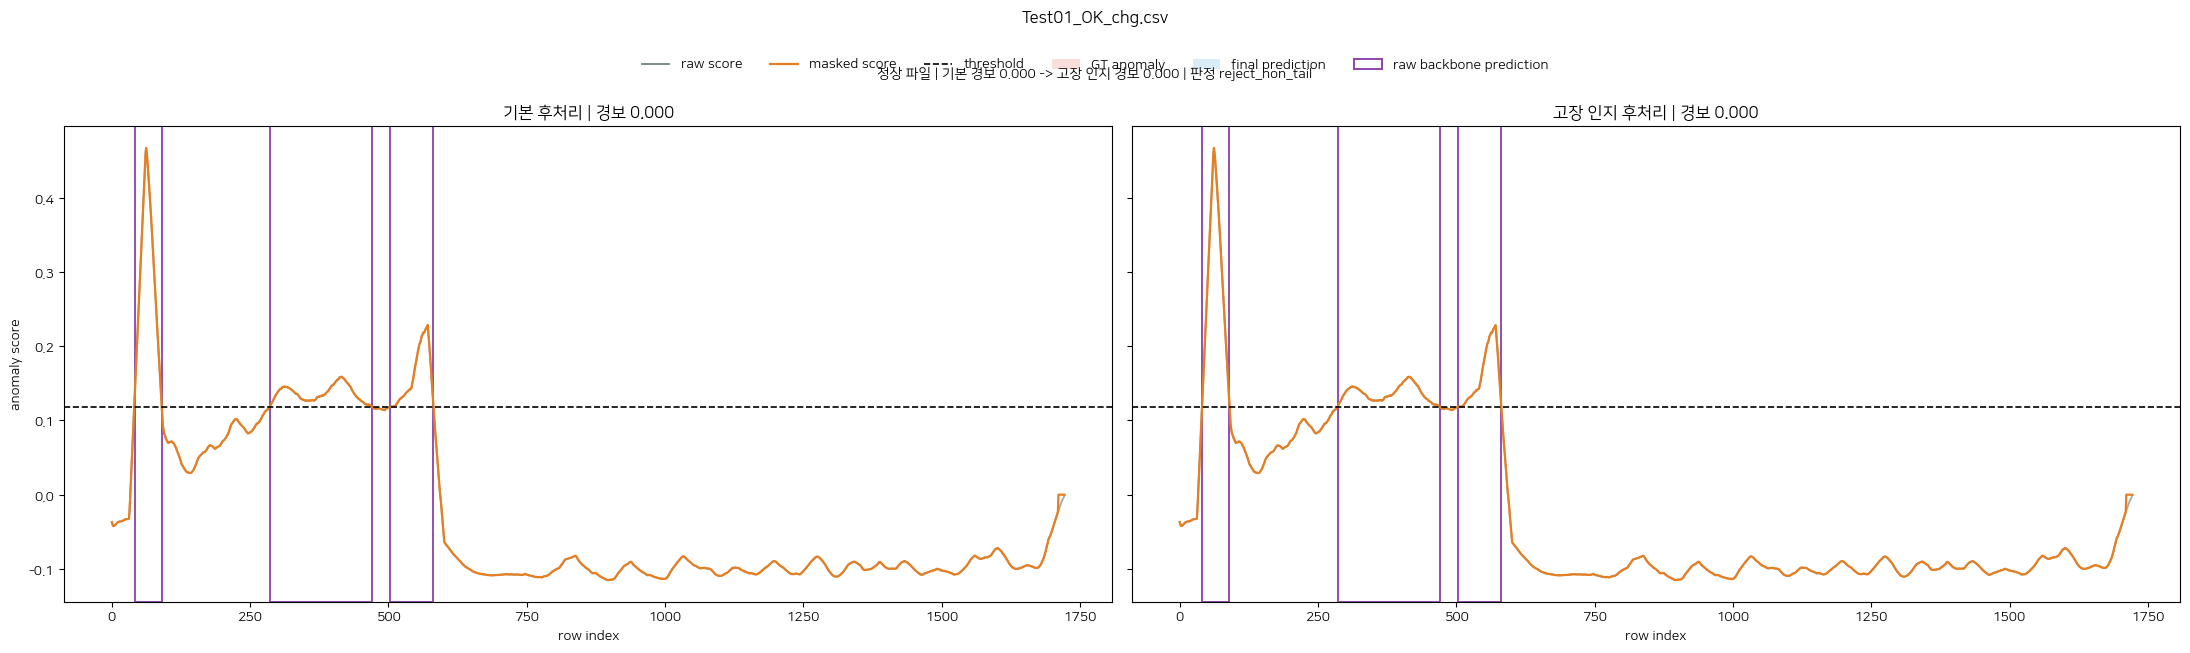

[Test02_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


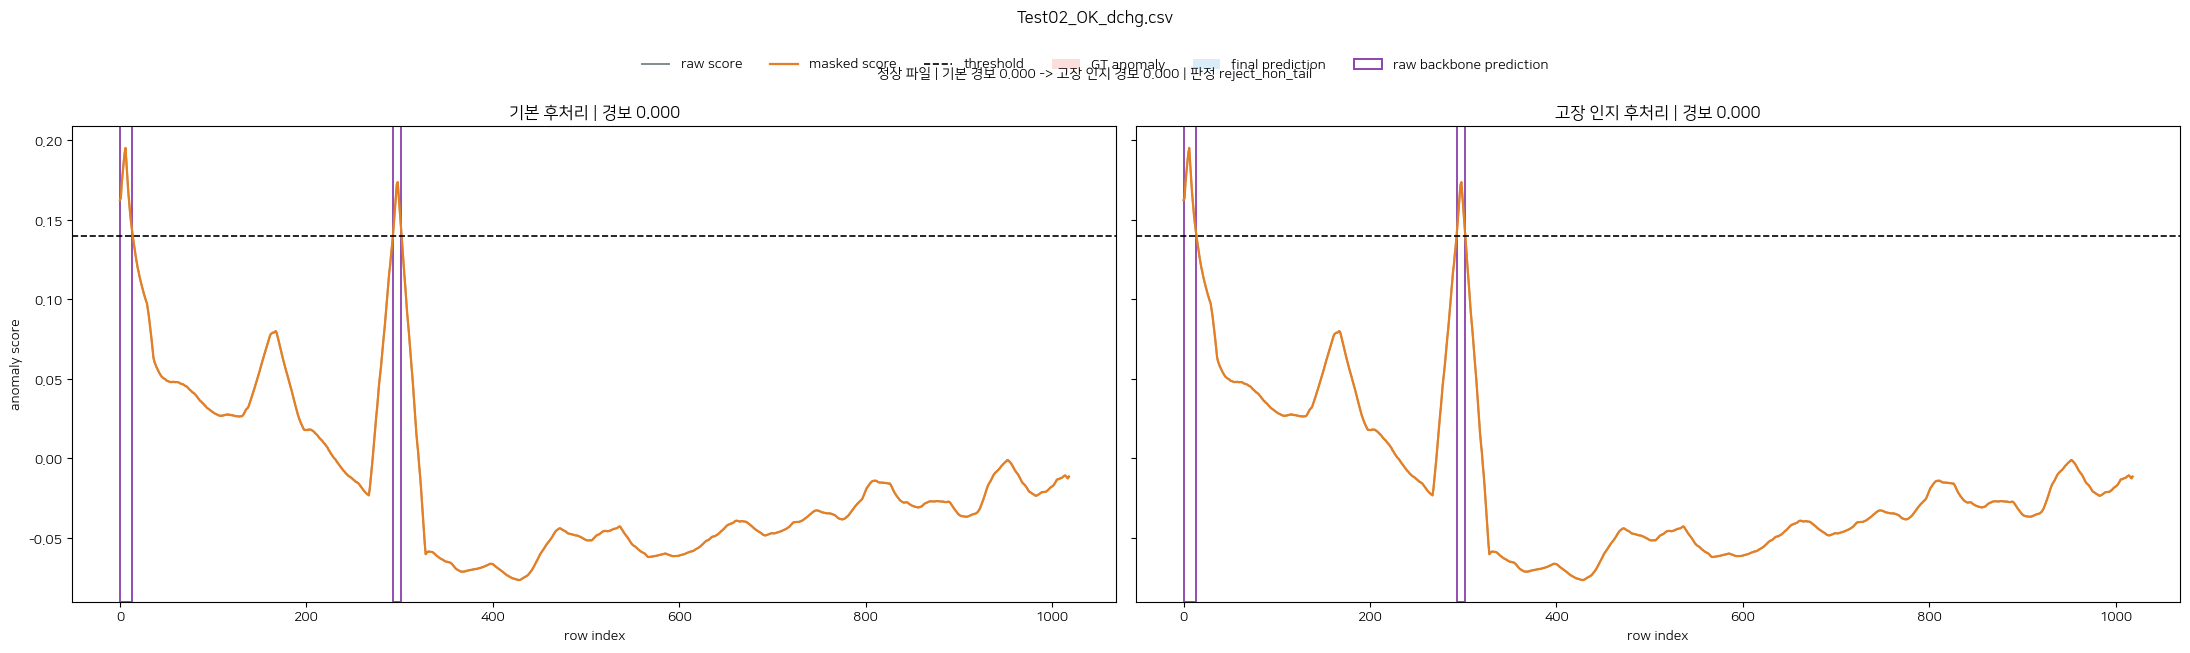

[Test03_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


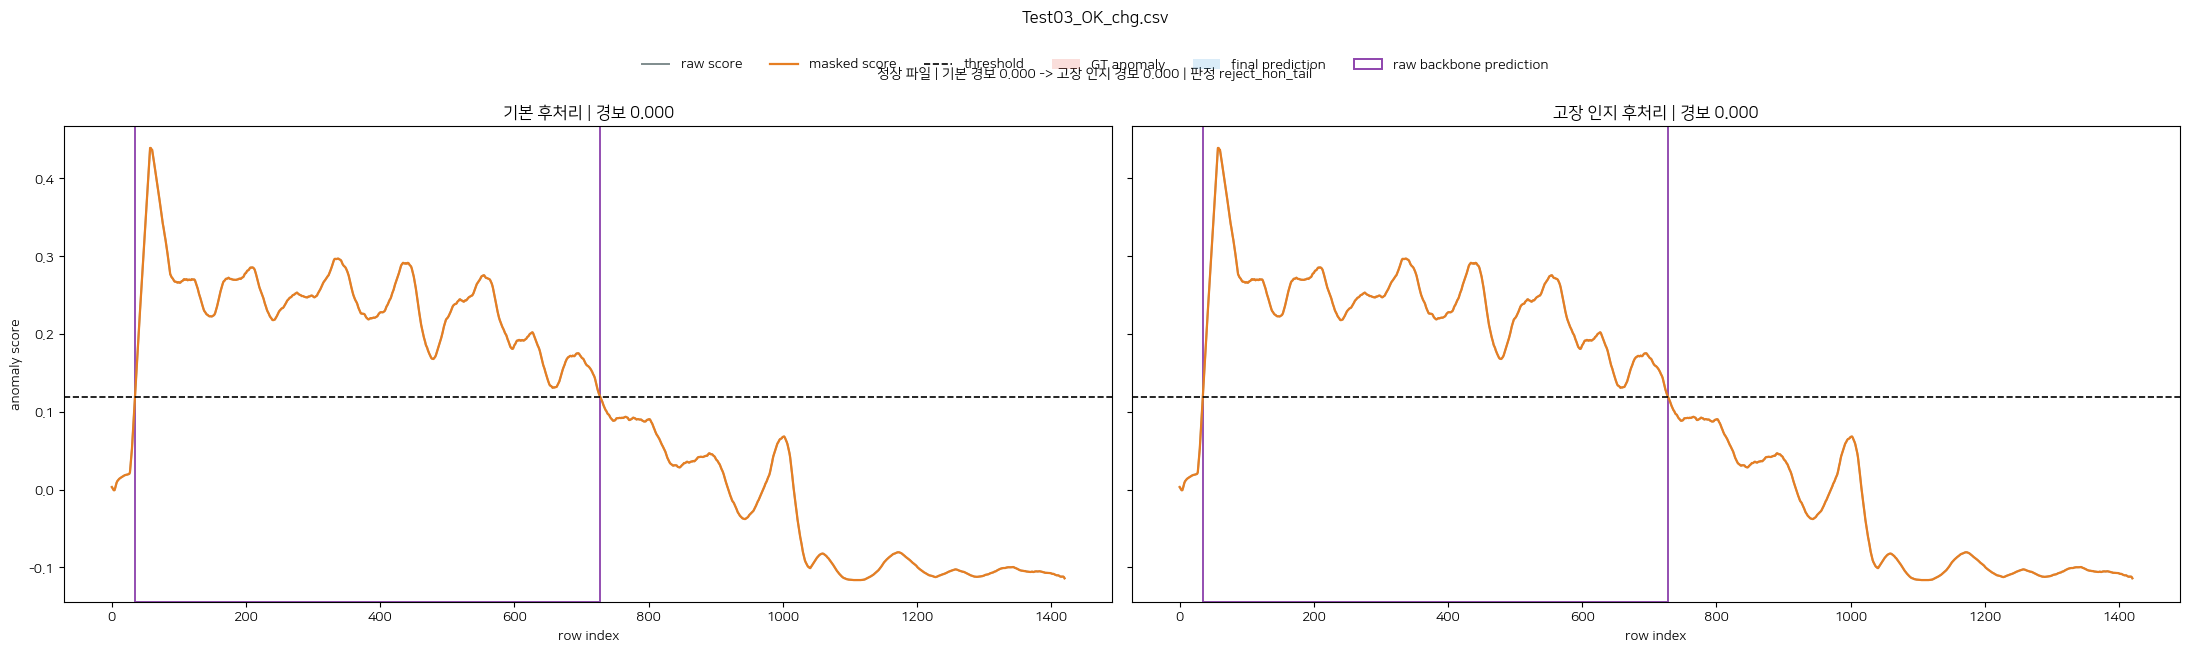

[Test04_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


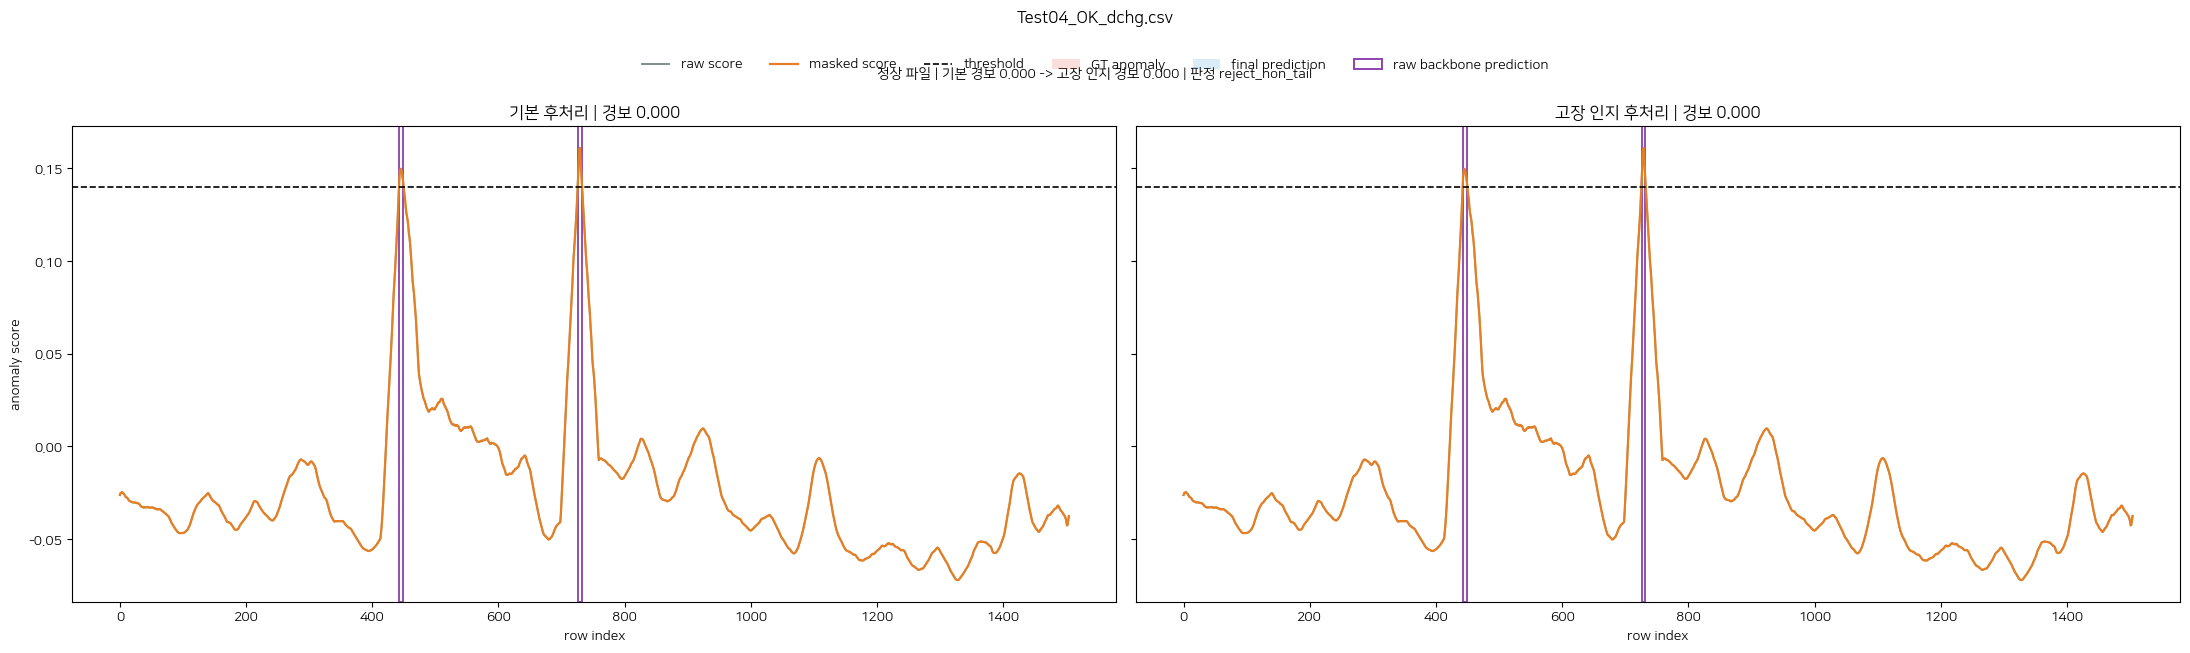

[Test05_NG_chg.csv] 실제 이상 0.849 | 기본 F1 0.555 -> 고장 인지 F1 0.974 | 판정 fault_support_component_merge | 고장유형 센싱와이어불량


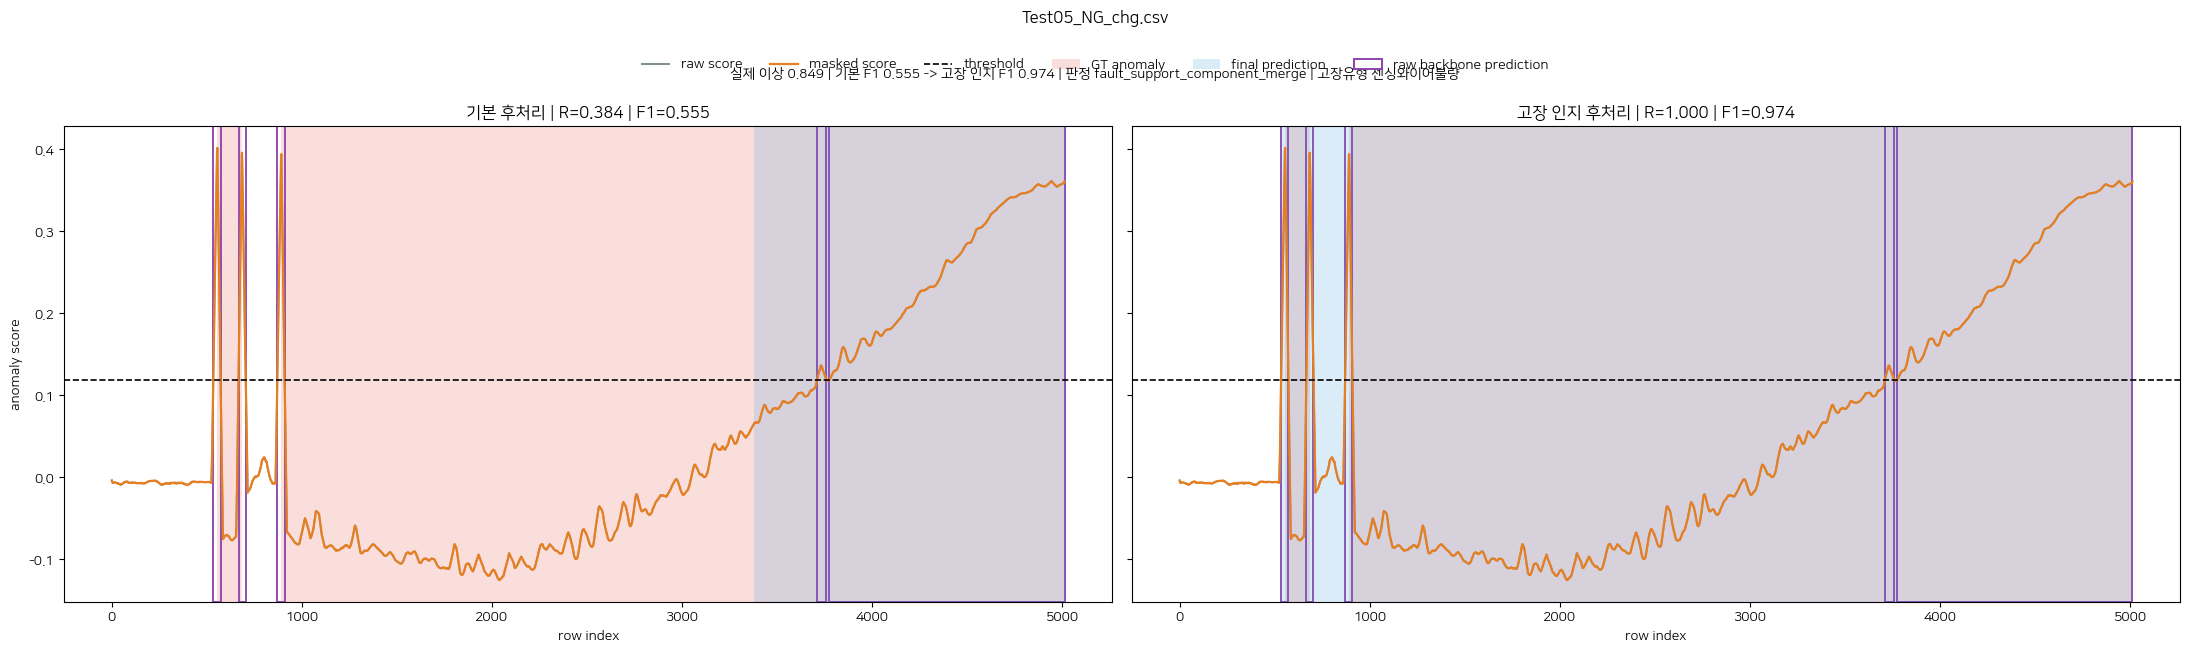

[Test06_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센싱와이어불량


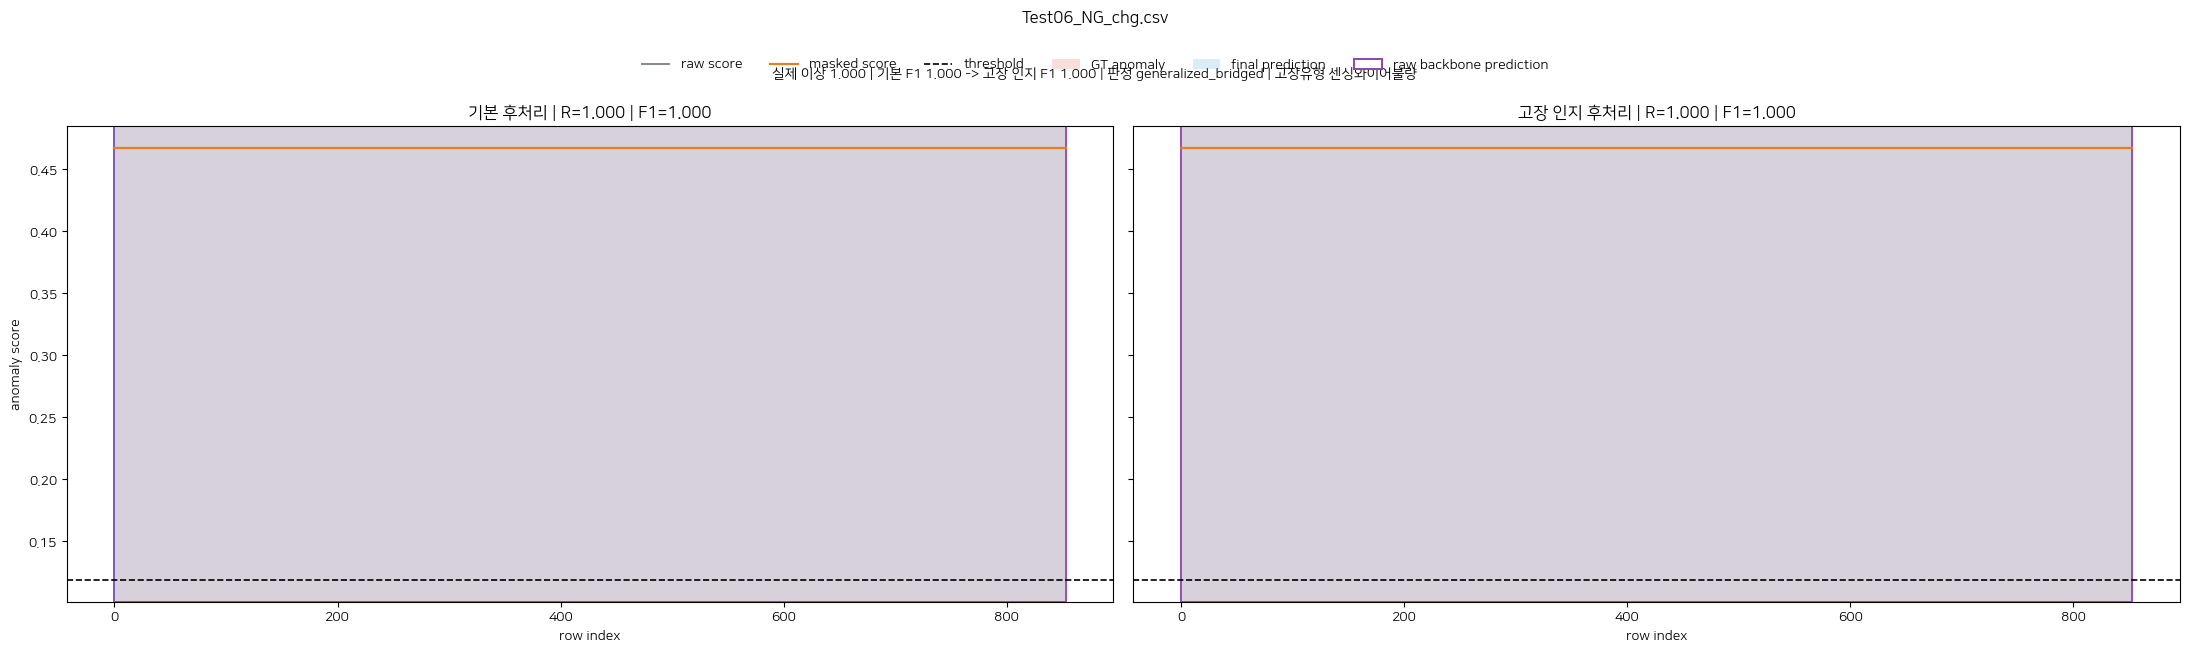

[Test07_NG_dchg.csv] 실제 이상 0.049 | 기본 F1 0.727 -> 고장 인지 F1 0.987 | 판정 fault_support_component_merge | 고장유형 센싱와이어불량


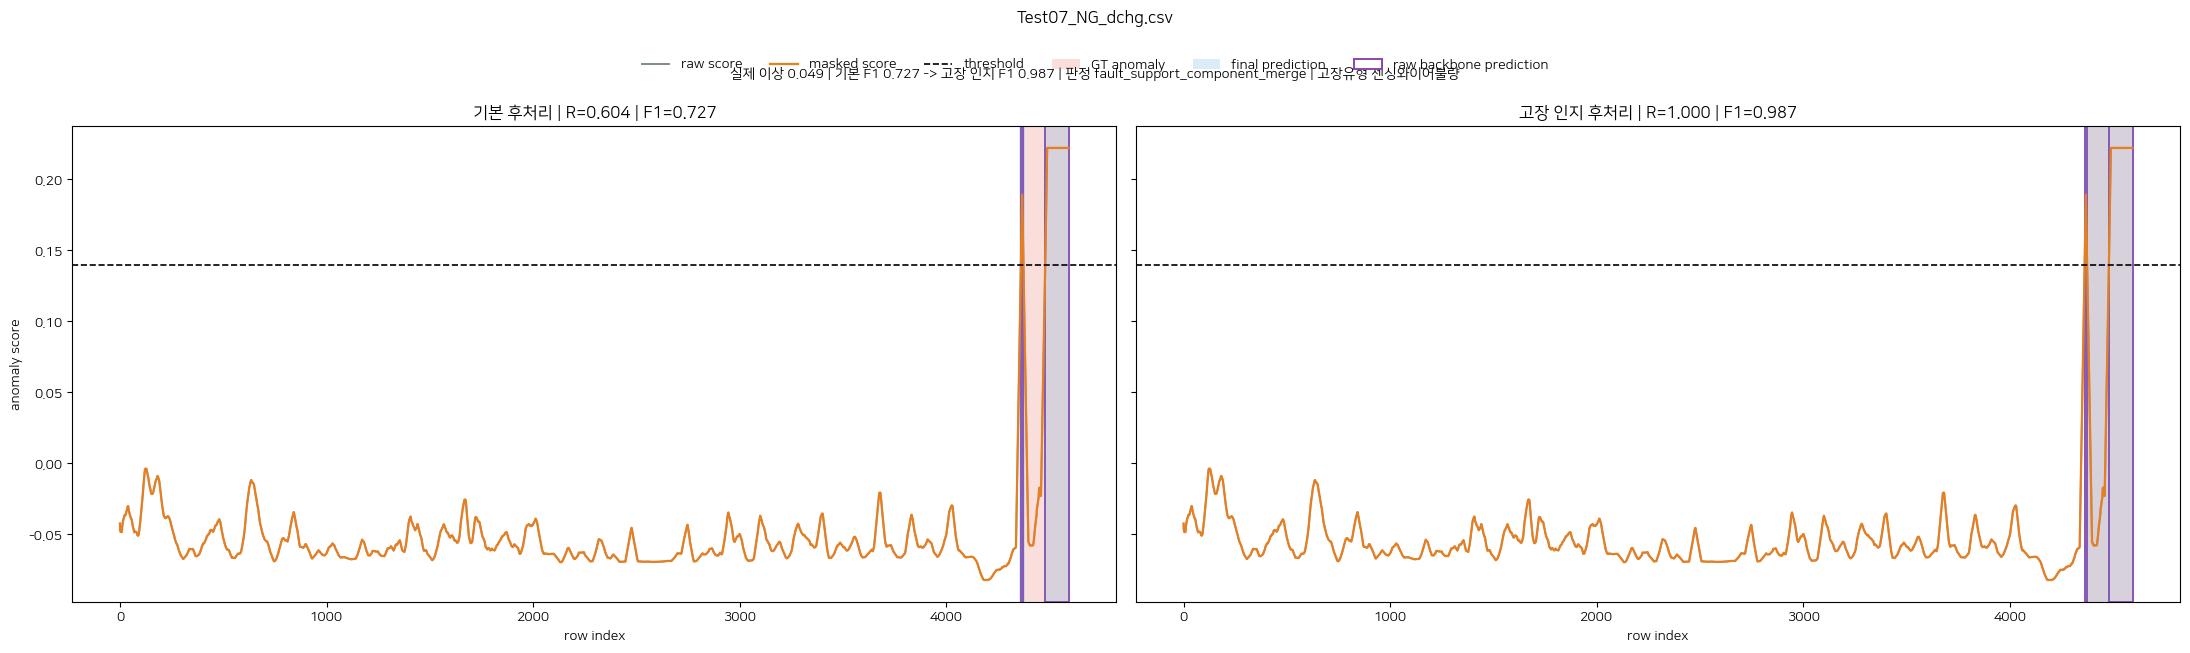

[Test08_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센서불량


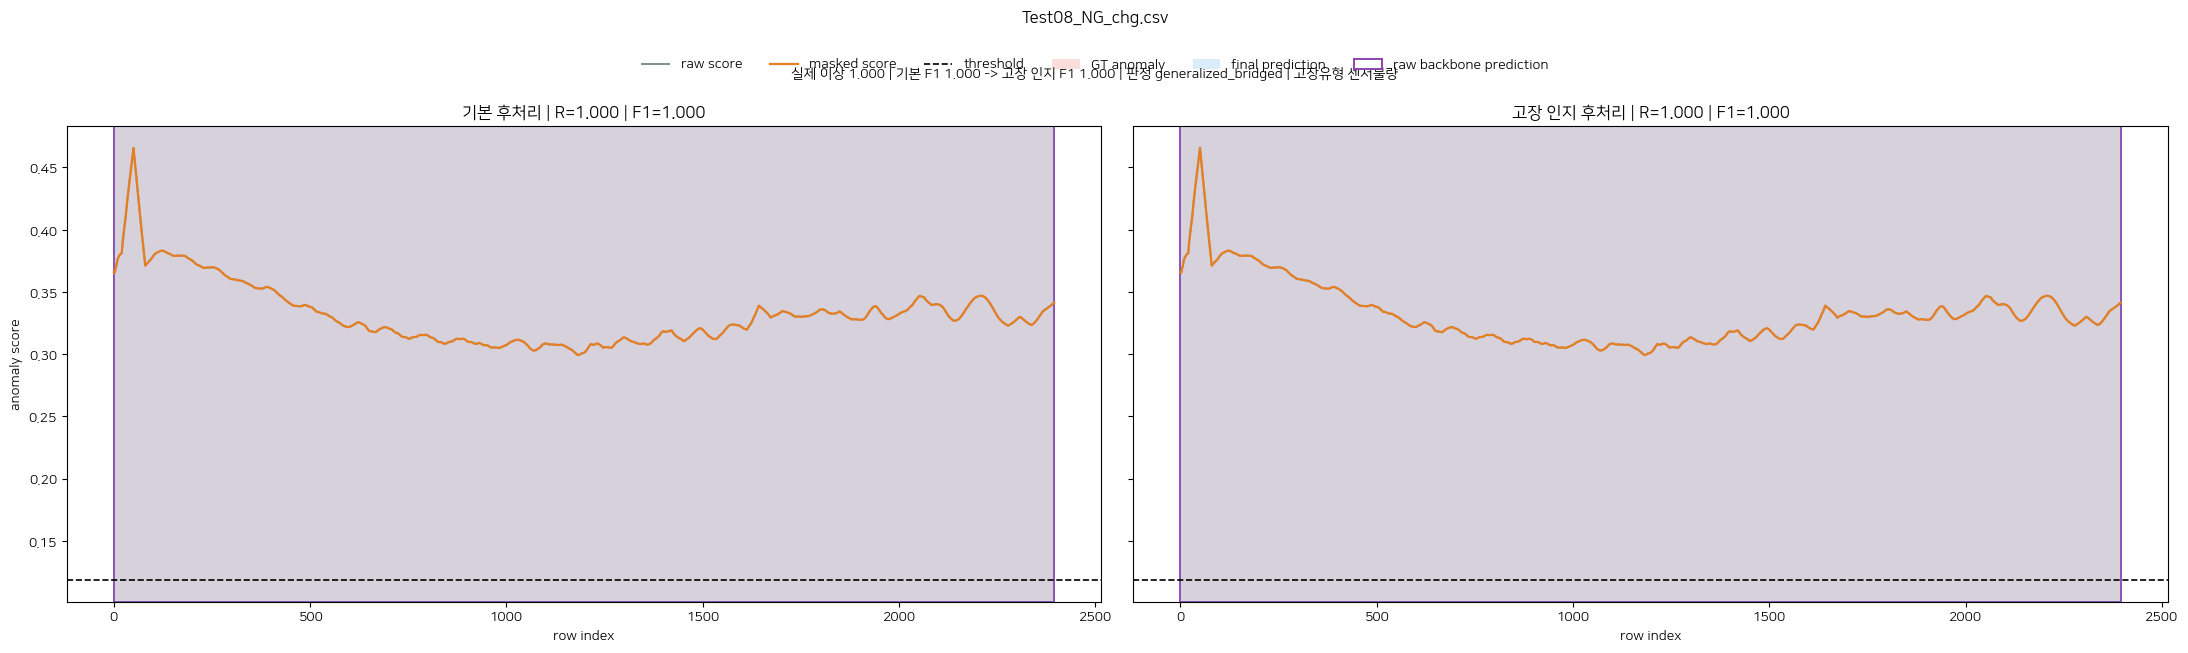

[Test09_NG_dchg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 fault_support_component_merge | 고장유형 센서불량


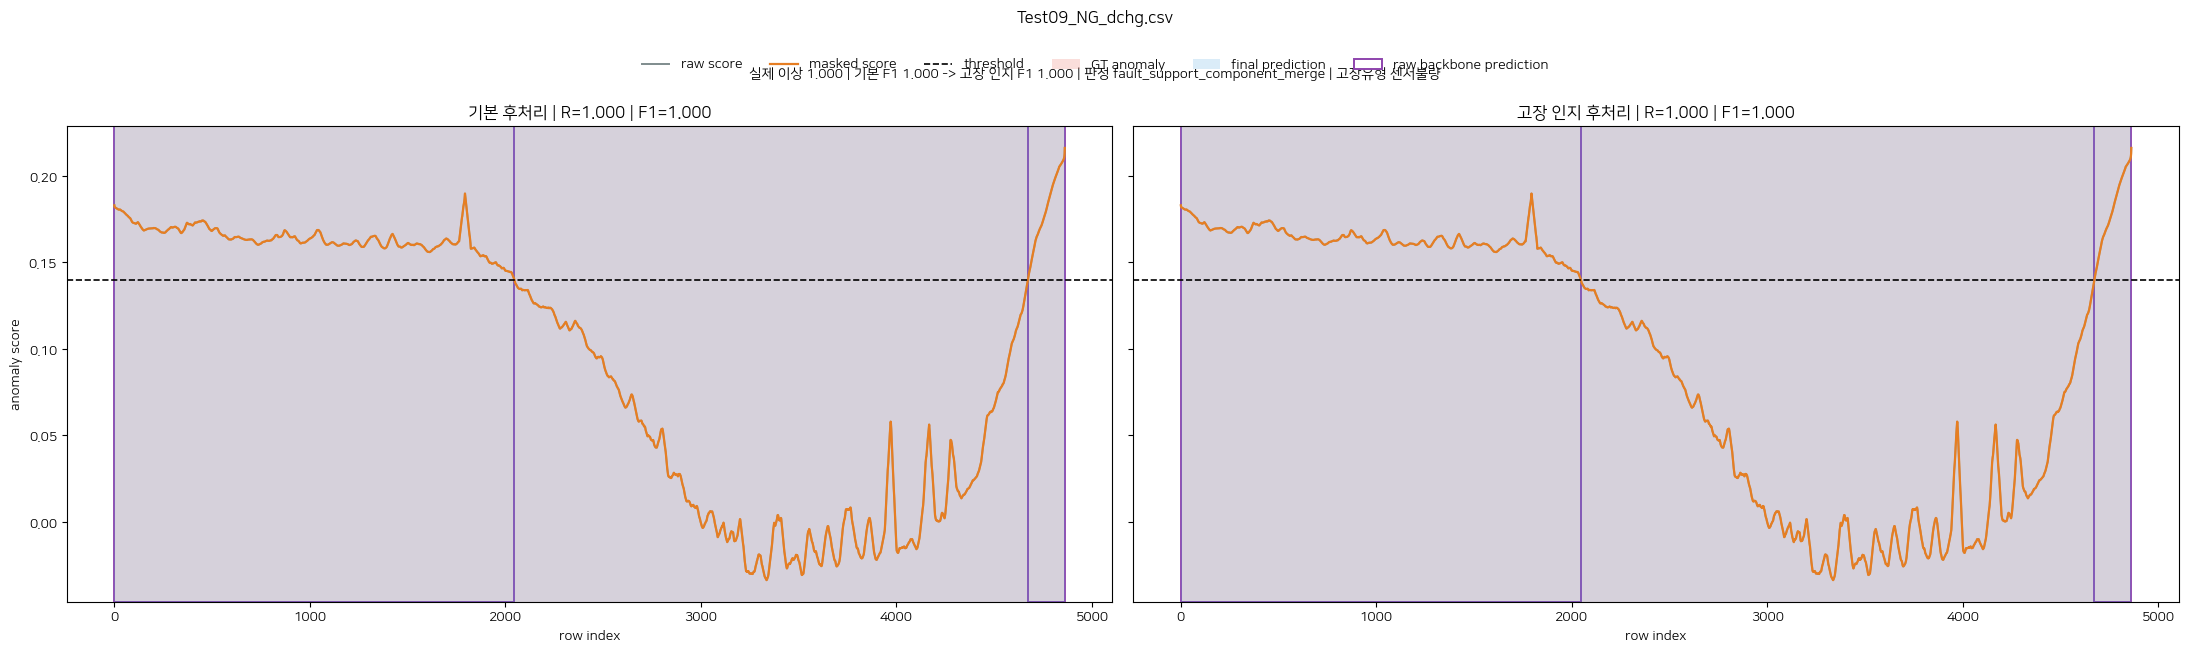

In [56]:
fault_name_map = {
    None: None,
    'capacity_fault': '용량불량',
    'weld_fault': '용접불량',
    'sensing_wire_fault': '센싱와이어불량',
    'sensor_fault': '센서불량',
}
general_detail_map = {row['test_name']: row['detail'] for _, row in train_general_results_df.iterrows()}
fault_detail_map = {row['test_name']: row['detail'] for _, row in train_fault_results_df.iterrows()}

for test_name in TEST_FILES:
    general_row = train_general_results_df.loc[train_general_results_df['test_name'] == test_name].iloc[0]
    fault_row = train_fault_results_df.loc[train_fault_results_df['test_name'] == test_name].iloc[0]
    inferred_fault_name = (
        fault_name_map.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    if float(fault_row['gt_ratio']) == 0.0:
        summary_text = (
            f"정상 파일 | "
            f"기본 경보 {general_row['final_pred_ratio']:.3f} -> 고장 인지 경보 {fault_row['final_pred_ratio']:.3f} | "
            f"판정 {fault_row['accept_reason']}"
        )
        left_title = f"기본 후처리 | 경보 {general_row['final_pred_ratio']:.3f}"
        right_title = f"고장 인지 후처리 | 경보 {fault_row['final_pred_ratio']:.3f}"
    else:
        summary_text = (
            f"실제 이상 {fault_row['gt_ratio']:.3f} | "
            f"기본 F1 {general_row['final_f1']:.3f} -> 고장 인지 F1 {fault_row['final_f1']:.3f} | "
            f"판정 {fault_row['accept_reason']} | "
            f"고장유형 {inferred_fault_name}"
        )
        left_title = f"기본 후처리 | R={general_row['final_recall']:.3f} | F1={general_row['final_f1']:.3f}"
        right_title = f"고장 인지 후처리 | R={fault_row['final_recall']:.3f} | F1={fault_row['final_f1']:.3f}"
    print(f"[{test_name}] {summary_text}")

    plot_detail_pair(
        general_detail_map[test_name],
        fault_detail_map[test_name],
        left_title=left_title,
        right_title=right_title,
        suptitle=test_name,
        summary_text=summary_text,
    )